## 제거 변수

빈점포율

pred

residual

risk_index

risk_group

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # Windows
plt.rcParams["axes.unicode_minus"] = False


In [2]:
import pandas as pd

df_od = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_od_label.csv", encoding="utf-8-sig")
#df_od = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od_support.csv", encoding="utf-8-sig")

In [3]:
df_od.iloc[:, ].columns

Index(['행정기관코드', '시장명', '시도', '시군구', '위도', '경도', '시장면적', '전체점포', '노점수',
       '총시장상인', '편의시설수', '점포_대_상인_비율', 'parking', 'bus', 'mart', 'tour',
       'conv', 'subway', 'pop_adole', 'pop_young', 'pop_middle', 'pop_senior',
       '지원여부', 'has_assoc', 'join_stores', 'item_diversity', 'is_food_based',
       'has_nonfood', 'delivery_grocery', '빈점포율', 'od_adole', 'od_young',
       'od_middle', 'od_senior', 'od_consumption', 'od_workedu',
       'od_residential', 'od_in_weekday', 'od_in_holiday', 'od_modal_car',
       'od_modal_walk', 'od_modal_bus', 'od_modal_sub', 'od_modal_etc',
       'stay_adole', 'stay_young', 'stay_middle', 'stay_senior',
       'stay_consumption', 'stay_workedu', 'stay_residential', 'stay_weekday',
       'stay_holiday', 'stay_morning', 'stay_lunch', 'stay_evening',
       'stay_night', 'market_item_type_먹거리/외식형',
       'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형',
       'market_item_type_생활형(장보기형)', 'market_item_type_서비스형', 'pred',
       'resid

In [ ]:
#df_od = df_od[df_od["시도"] == "경상북도"].copy()


In [155]:
q30 = df_od["risk_index"].quantile(0.3)
q70 = df_od["risk_index"].quantile(0.7)

df_low  = df_od[df_od["risk_index"] <= q30]   # 하위 30%
df_high = df_od[df_od["risk_index"] >= q70]   # 상위 30%


In [156]:
# ============================================================
# "변수 묶음별" PCA + (선택) MCA
# - all_features 전체를 한 번에 PCA하지 않고,
#   struct / sales / resident / od / stay / access 그룹별로 따로 PCA
# - PCA 컴포넌트 수는 "누적 설명분산 >= 0.70"을 만족하는 최소 개수로 자동 선택
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# MCA 라이브러리 (없으면 설치)
# !pip install prince
import prince


# -----------------------------
# 0) 입력: df, 변수 리스트
# -----------------------------
# df = market_df.copy()

market_item_dummies = [
    'market_item_type_먹거리/외식형',
    'market_item_type_복합형(생활+비식품)',
    'market_item_type_비식품/전문형',
    'market_item_type_생활형(장보기형)',
    'market_item_type_서비스형'
]

struct_vars = [
    '시장면적','전체점포','노점수','총시장상인','편의시설수',
    '점포_대_상인_비율','has_assoc','join_stores'
]
sales_vars = [
    'item_diversity','is_food_based','has_nonfood','delivery_grocery','market_item_type'
]
resident_vars = ['pop_adole','pop_young','pop_middle','pop_senior']
od_vars = [
    'od_adole','od_young','od_middle','od_senior','od_consumption','od_workedu',
    'od_residential','od_in_weekday','od_in_holiday','od_modal_car','od_modal_walk',
    'od_modal_bus','od_modal_sub','od_modal_etc'
]
stay_vars = [
    'stay_adole','stay_young','stay_middle','stay_senior',
    'stay_consumption','stay_workedu','stay_residential','stay_weekday',
    'stay_holiday','stay_morning','stay_lunch','stay_evening','stay_night'
]
access_vars = ['parking','bus','mart','tour','conv','subway']

# policy_vars = ['지원여부']  # 요청대로 PCA/MCA에서 제외할 수 있음


# -----------------------------
# 1) market_item_type 더미 -> 범주형 복원
# -----------------------------
def restore_market_item_type(df: pd.DataFrame,
                             dummy_cols: list,
                             new_col: str = "market_item_type",
                             unknown_label: str = "미분류",
                             drop_dummies: bool = True) -> pd.DataFrame:
    df = df.copy()
    dummy_cols_exist = [c for c in dummy_cols if c in df.columns]

    # 이미 범주형 컬럼이 존재하면 그대로 사용
    if new_col in df.columns and len(dummy_cols_exist) == 0:
        return df

    if len(dummy_cols_exist) == 0:
        raise ValueError("market_item_type 더미 컬럼이 df에 없습니다.")

    dummy_mat = df[dummy_cols_exist].fillna(0)
    row_sum = dummy_mat.sum(axis=1)
    argmax_col = dummy_mat.idxmax(axis=1)

    labels = argmax_col.str.replace("market_item_type_", "", regex=False)
    labels = labels.where(row_sum > 0, other=unknown_label)

    df[new_col] = labels

    if drop_dummies:
        df.drop(columns=dummy_cols_exist, inplace=True, errors="ignore")

    return df


df_high_2 = restore_market_item_type(df_high, market_item_dummies, new_col="market_item_type")



import numpy as np
import pandas as pd

df_ratio = df_high_2.copy()

# -------------------------
# RESIDENT 비율
# -------------------------
pop_cols = ['pop_adole','pop_young','pop_middle','pop_senior']
df_ratio['pop_total'] = df_ratio[pop_cols].sum(axis=1)

for c in pop_cols:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['pop_total'] > 0,
        df_ratio[c] / df_ratio['pop_total'],
        0
    )

resident_ratio_vars = [f'{c}_ratio' for c in pop_cols]


# -------------------------
# OD 비율
# -------------------------
od_age_cols = ['od_adole','od_young','od_middle','od_senior']
od_total_cols = [
    'od_adole','od_young','od_middle','od_senior',
    'od_consumption','od_workedu','od_residential'
]

df_ratio['od_total'] = df_ratio[od_total_cols].sum(axis=1)

for c in od_age_cols + ['od_consumption','od_workedu','od_residential']:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['od_total'] > 0,
        df_ratio[c] / df_ratio['od_total'],
        0
    )

# 시간/수단 비율
df_ratio['od_day_ratio'] = np.where(
    df_ratio['od_in_weekday'] + df_ratio['od_in_holiday'] > 0,
    df_ratio['od_in_weekday'] / (df_ratio['od_in_weekday'] + df_ratio['od_in_holiday']),
    0
)

modal_cols = ['od_modal_car','od_modal_walk','od_modal_bus','od_modal_sub','od_modal_etc']
df_ratio['od_modal_total'] = df_ratio[modal_cols].sum(axis=1)

for c in modal_cols:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['od_modal_total'] > 0,
        df_ratio[c] / df_ratio['od_modal_total'],
        0
    )

od_ratio_vars = (
    [f'{c}_ratio' for c in od_age_cols] +
    ['od_consumption_ratio','od_workedu_ratio','od_residential_ratio',
     'od_day_ratio'] +
    [f'{c}_ratio' for c in modal_cols]
)


# -------------------------
# STAY 비율
# -------------------------
stay_age_cols = ['stay_adole','stay_young','stay_middle','stay_senior']
stay_time_cols = ['stay_morning','stay_lunch','stay_evening','stay_night']
stay_total_cols = stay_age_cols + stay_time_cols + [
    'stay_consumption','stay_workedu','stay_residential'
]

df_ratio['stay_total'] = df_ratio[stay_total_cols].sum(axis=1)

for c in stay_age_cols + stay_time_cols + ['stay_consumption','stay_workedu','stay_residential']:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['stay_total'] > 0,
        df_ratio[c] / df_ratio['stay_total'],
        0
    )

stay_ratio_vars = (
    [f'{c}_ratio' for c in stay_age_cols] +
    [f'{c}_ratio' for c in stay_time_cols] +
    ['stay_consumption_ratio','stay_workedu_ratio','stay_residential_ratio']
)


In [151]:

# -----------------------------
# 2) 그룹별 PCA를 위해 "연속형만" 추출하는 헬퍼
# -----------------------------
def pick_existing(df: pd.DataFrame, cols: list) -> list:
    return [c for c in cols if c in df.columns]

def make_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    out = df[cols].copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def median_impute_numeric(X: pd.DataFrame) -> pd.DataFrame:
    return X.fillna(X.median(numeric_only=True))


def pca_fit_transform_auto_n(
    X: pd.DataFrame,
    var_threshold: float = 0.70,
    random_state: int = 88,
    log_transform: bool = True,
    log_method: str = "log1p",   # "log1p" 권장 (0 포함 데이터 안전)
    clip_negative_to_zero: bool = True
):
    """
    X: numeric DataFrame
    - (옵션) log 변환 -> StandardScaler -> PCA
    - 누적 설명분산 >= var_threshold 를 만족하는 최소 n_components 자동 선택

    Parameters
    ----------
    log_transform : bool
        True면 PCA 전에 로그변환 수행
    log_method : {"log1p","log"}
        - "log1p": log(1+x), 0 포함 안전 (zero-inflated에 권장)
        - "log": log(x), x>0 필요 (0 있으면 깨짐)
    clip_negative_to_zero : bool
        로그변환 전에 음수를 0으로 클리핑(카운트/규모형 변수에서 안전장치)

    Returns
    -------
    pca_pipe : Pipeline
    Z : np.ndarray (scores)
    loadings_df : pd.DataFrame
    explained_df : pd.DataFrame
    n_opt : int
    """

    # 0) 숫자형 강제 + 결측 처리(중앙값)
    Xn = X.copy()
    for c in Xn.columns:
        Xn[c] = pd.to_numeric(Xn[c], errors="coerce")
    Xn = Xn.fillna(Xn.median(numeric_only=True))

    # 1) 로그변환 (zero-inflated 대응)
    if log_transform:
        Xv = Xn.values.astype(float)

        if clip_negative_to_zero:
            Xv = np.maximum(Xv, 0.0)

        if log_method == "log1p":
            Xv = np.log1p(Xv)
        elif log_method == "log":
            # log는 0/음수 있으면 불가 -> 아주 작은 양수로 치환
            eps = 1e-12
            Xv = np.log(np.maximum(Xv, eps))
        else:
            raise ValueError("log_method must be 'log1p' or 'log'.")

        Xn = pd.DataFrame(Xv, columns=Xn.columns, index=Xn.index)

    # 2) StandardScaler
    scaler = StandardScaler()
    Xs = scaler.fit_transform(Xn.values)

    # 3) full PCA로 누적 설명분산 확인
    max_comp = min(Xn.shape[1], Xn.shape[0] - 1)
    max_comp = max(1, max_comp)

    pca_full = PCA(n_components=max_comp, random_state=random_state)
    pca_full.fit(Xs)

    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n_opt = int(np.searchsorted(cum, var_threshold) + 1)
    n_opt = max(1, min(n_opt, pca_full.n_components_))

    # 4) 최적 n으로 다시 fit_transform
    pca = PCA(n_components=n_opt, random_state=random_state)
    Z = pca.fit_transform(Xs)

    comp_names = [f"PC{i+1}" for i in range(n_opt)]
    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=Xn.columns,
        columns=comp_names
    )

    explained_df = pd.DataFrame({
        "component": comp_names,
        "explained_ratio": pca.explained_variance_ratio_,
        "cum_explained_ratio": np.cumsum(pca.explained_variance_ratio_)
    })

    # 5) 파이프라인 반환
    #   - 스케일러/ PCA만 묶고, 로그변환은 함수 내부에서 처리(명시적)
    pca_pipe = Pipeline([("scaler", scaler), ("pca", pca)])

    return pca_pipe, Z, loadings_df, explained_df, n_opt




In [157]:
from sklearn.preprocessing import StandardScaler

# -------------------------
# RESIDENT PCA
# -------------------------
X_res = df_ratio[resident_ratio_vars]
_, Z_res, load_res, exp_res, n_res = pca_fit_transform_auto_n(
    X_res, var_threshold=0.70
)

resident_pca = pd.DataFrame(
    Z_res,
    columns=[f'RESIDENT_PC{i+1}' for i in range(n_res)],
    index=df_ratio.index
)

# -------------------------
# OD PCA
# -------------------------
X_od = df_ratio[od_ratio_vars]
_, Z_od, load_od, exp_od, n_od = pca_fit_transform_auto_n(
    X_od, var_threshold=0.70
)

od_pca = pd.DataFrame(
    Z_od,
    columns=[f'OD_PC{i+1}' for i in range(n_od)],
    index=df_ratio.index
)

# -------------------------
# STAY PCA
# -------------------------
X_stay = df_ratio[stay_ratio_vars]
_, Z_stay, load_stay, exp_stay, n_stay = pca_fit_transform_auto_n(
    X_stay, var_threshold=0.70
)

stay_pca = pd.DataFrame(
    Z_stay,
    columns=[f'STAY_PC{i+1}' for i in range(n_stay)],
    index=df_ratio.index
)

In [158]:
load_res

,PC1,PC2
pop_adole_ratio,-0.475083,-0.521683
pop_young_ratio,-0.396580,0.702100
pop_middle_ratio,-0.525815,-0.384971
pop_senior_ratio,0.583557,-0.294448


In [130]:
load_od

,PC1,PC2,PC3,PC4
od_adole_ratio,0.083600,-0.155608,-0.315208,0.555677
od_young_ratio,-0.260841,0.160722,-0.196966,-0.534555
od_middle_ratio,0.198531,-0.064931,0.534448,-0.027315
od_senior_ratio,0.241870,-0.117546,0.353308,0.194372
od_consumption_ratio,-0.377792,0.273651,-0.009386,0.297219
od_workedu_ratio,0.058919,0.449028,0.417363,-0.030346
od_residential_ratio,0.279478,-0.484702,-0.187390,-0.268524
od_day_ratio,0.376993,-0.010275,0.189167,-0.233230
od_modal_car_ratio,-0.302135,-0.304644,0.194921,0.052665
od_modal_walk_ratio,0.348730,0.203236,-0.371953,-0.070607


In [131]:
load_stay

,PC1,PC2,PC3
stay_adole_ratio,-0.329781,0.245634,0.074428
stay_young_ratio,-0.045410,0.581294,-0.058477
stay_middle_ratio,0.214987,0.034127,0.445774
stay_senior_ratio,0.214918,-0.485716,0.269614
stay_morning_ratio,0.150129,-0.119347,0.489875
stay_lunch_ratio,0.421738,0.167392,0.245394
stay_evening_ratio,0.061218,0.439361,0.398840
stay_night_ratio,-0.406685,0.122312,0.296900
stay_consumption_ratio,0.375059,0.063076,-0.077824
stay_workedu_ratio,0.362072,0.320232,-0.069078


In [160]:
# -----------------------------
# 3) 그룹별 PCA 실행
#    - 범주/이진형은 PCA에서 제외 (요청대로)
# -----------------------------
# 그룹 내에서 PCA에 넣을 "연속형 후보"를 명시적으로 구성
# (is_food_based/has_nonfood/delivery_grocery/market_item_type/has_assoc 등은 제외)

struct_pca_cols = pick_existing(df_high_2, [
    '시장면적','전체점포','노점수','총시장상인','편의시설수','점포_대_상인_비율','join_stores'
    # has_assoc 제외
])

sales_pca_cols = pick_existing(df_high_2, [
    'item_diversity'
    # is_food_based/has_nonfood/delivery_grocery/market_item_type 제외
])

#resident_pca_cols = pick_existing(df_od_2, resident_vars)

#od_pca_cols = pick_existing(df_od_2, od_vars)

#stay_pca_cols = pick_existing(df_od_2, stay_vars)

access_pca_cols = pick_existing(df_high_2, access_vars)

group_map = {
    "STRUCT": struct_pca_cols,
    "SALES": sales_pca_cols,
    #"RESIDENT": resident_pca_cols,
    #"OD": od_pca_cols,
    #"STAY": stay_pca_cols,
    "ACCESS": access_pca_cols
}

VAR_THRESHOLD = 0.70

group_scores = {}
group_loadings = {}
group_explained = {}
group_nopt = {}
group_pipes = {}

for gname, cols in group_map.items():
    if len(cols) < 2:
        # 변수가 0~1개면 PCA 불가/의미 약함 -> 원변수 그대로 쓰거나 스킵
        print(f"[SKIP] {gname}: usable numeric cols < 2 -> {cols}")
        continue

    Xg = make_numeric(df_high_2, cols)
    Xg = median_impute_numeric(Xg)

    pipe, Z, loadings_df, explained_df, n_opt = pca_fit_transform_auto_n(
        Xg, var_threshold=VAR_THRESHOLD, random_state=88
    )

    # 점수 DataFrame
    comp_names = [f"{gname}_PC{i+1}" for i in range(n_opt)]
    scores_df = pd.DataFrame(Z, columns=comp_names, index=df_high_2.index)

    # 저장
    group_scores[gname] = scores_df
    group_loadings[gname] = loadings_df.rename(columns={c: f"{gname}_{c}" for c in loadings_df.columns})
    group_explained[gname] = explained_df.assign(group=gname)
    group_nopt[gname] = n_opt
    group_pipes[gname] = pipe

    print(f"[DONE] {gname}: n_opt={n_opt}, cum_explained={explained_df['cum_explained_ratio'].iloc[-1]:.3f}")


# 그룹별 PCA 임베딩 결합
pca_embed_df = pd.concat(group_scores.values(), axis=1) if len(group_scores) else pd.DataFrame(index=df_high_2.index)

[DONE] STRUCT: n_opt=3, cum_explained=0.759
[SKIP] SALES: usable numeric cols < 2 -> ['item_diversity']
[DONE] ACCESS: n_opt=3, cum_explained=0.756


In [161]:

# -----------------------------
# 4) (선택) 범주/이진형은 MCA로 따로 축약
# -----------------------------
# 요청대로: market_item_type(범주), is_food_based/has_nonfood/delivery_grocery(이진), has_assoc(이진)
mca_cols = pick_existing(df_high_2, ['market_item_type','is_food_based','has_nonfood','delivery_grocery','has_assoc'])

def prep_for_mca(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    X = df[cols].copy()
    for c in cols:
        if X[c].dtype.kind in "biufc":
            X[c] = X[c].fillna(0).astype(int).astype(str)
        else:
            X[c] = X[c].fillna("미분류").astype(str)
    return X

n_mca = 3  # 필요시 조절(또는 PCA처럼 threshold로 자동선정은 MCA에서는 해석이 애매해서 보통 고정)
if len(mca_cols) >= 2:
    X_mca = prep_for_mca(df_high_2, mca_cols)

    mca = prince.MCA(
        n_components=n_mca,
        n_iter=5,
        copy=True,
        check_input=True,
        engine="sklearn",
        random_state=88
    )
    mca_scores = mca.fit_transform(X_mca)
    mca_embed_df = pd.DataFrame(
        mca_scores.values,
        columns=[f"MCA_{i+1}" for i in range(n_mca)],
        index=df_high_2.index
    )
else:
    mca_embed_df = pd.DataFrame(index=df_high_2.index)


mca_loadings = mca.column_coordinates(X_mca)

# -----------------------------
# 5) 최종 임베딩: (그룹별 PCA) + (MCA)
# -----------------------------
embed_df = pd.concat([pca_embed_df, resident_pca, od_pca, stay_pca, mca_embed_df], axis=1)

# 원본 df에 붙이기
df_embed = pd.concat([df_high_2, embed_df], axis=1)


# 그룹별 설명력 요약표
explained_all = pd.concat(group_explained.values(), axis=0) if len(group_explained) else pd.DataFrame()

print("\n=== Group-wise PCA optimal n_components (cum>=0.70) ===")
print(pd.Series(group_nopt).sort_index())

print("\n=== Embedding shape ===")
print(embed_df.shape)

# 해석용: 특정 그룹 로딩 상위 확인 예시
# group_loadings["STAY"].sort_values("STAY_PC1", key=np.abs, ascending=False).head(15)
# explained_all.query("group=='STAY'")



=== Group-wise PCA optimal n_components (cum>=0.70) ===
ACCESS    3
STRUCT    3
dtype: int64

=== Embedding shape ===
(250, 18)


In [162]:
mca_loadings 

,0,1,2
market_item_type__먹거리/외식형,-1.264391,1.755588,-1.516800
market_item_type__복합형(생활+비식품),-0.015741,-0.523127,-0.014729
market_item_type__비식품/전문형,3.223949,1.880912,-1.207046
market_item_type__생활형(장보기형),-1.359368,1.843205,0.912774
market_item_type__서비스형,3.200718,1.729537,2.253330
is_food_based__0,3.214383,1.818581,0.217815
is_food_based__1,-0.234526,-0.132686,-0.015892
has_nonfood__0,-1.189075,1.542467,-0.080570
has_nonfood__1,0.289874,-0.376024,0.019641
delivery_grocery__0,0.030937,-0.016210,-0.121237


In [134]:
group_loadings

{'STRUCT':              STRUCT_PC1  STRUCT_PC2  STRUCT_PC3
 시장면적           0.370046   -0.123236    0.694718
 전체점포           0.465212    0.320991    0.182134
 노점수            0.212604   -0.611164   -0.161964
 총시장상인          0.521896    0.014652    0.101650
 편의시설수          0.365049    0.161839   -0.576754
 점포_대_상인_비율    -0.202016    0.653997    0.140416
 join_stores    0.393696    0.232673   -0.308655,
 'ACCESS':          ACCESS_PC1  ACCESS_PC2  ACCESS_PC3
 parking    0.330995    0.404693   -0.374513
 bus        0.285531    0.555538   -0.415836
 mart       0.531712   -0.135919   -0.007331
 tour       0.471524   -0.378684   -0.050509
 conv       0.172253    0.546281    0.785951
 subway     0.523632   -0.259428    0.257868}

In [113]:
df_od.iloc[:,6:-6]

,시장면적,전체점포,노점수,총시장상인,편의시설수,점포_대_상인_비율,parking,bus,mart,tour,...,stay_holiday,stay_morning,stay_lunch,stay_evening,stay_night,market_item_type_먹거리/외식형,market_item_type_복합형(생활+비식품),market_item_type_비식품/전문형,market_item_type_생활형(장보기형),market_item_type_서비스형
0,1668,90,4,110,10,0.781818,4,25,4,0,...,4291336.0,2578195.0,2470881.0,2600765.0,2634303.0,0,1,0,0,0
1,6628,83,49,191,10,0.434555,0,22,4,0,...,6910554.0,4072151.0,3833011.0,4244467.0,4591541.0,0,1,0,0,0
2,2205,52,43,103,7,0.485437,0,26,4,0,...,6910554.0,4072151.0,3833011.0,4244467.0,4591541.0,0,1,0,0,0
3,22230,252,100,471,12,0.528662,3,23,4,0,...,4291336.0,2578195.0,2470881.0,2600765.0,2634303.0,0,1,0,0,0
4,1198,62,0,46,13,1.000000,0,21,3,0,...,4291336.0,2578195.0,2470881.0,2600765.0,2634303.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,4146,57,0,61,11,0.885246,2,24,1,0,...,7207966.0,4329636.0,3931154.0,4254345.0,4690579.0,0,1,0,0,0
829,2645,104,24,114,8,0.736842,4,47,0,0,...,2085586.0,1585063.0,1586423.0,1402062.0,1190152.0,0,1,0,0,0
830,10116,74,44,113,16,0.610619,0,17,3,0,...,1634715.0,983014.0,1009246.0,934453.0,842174.0,0,1,0,0,0
831,30560,331,148,590,17,0.557627,6,40,0,0,...,16907027.0,10685220.0,10619197.0,10979927.0,11173999.0,0,1,0,0,0


     k      inertia  silhouette
0    2  3910.810018    0.143773
1    3  3448.200799    0.175462
2    4  3129.375908    0.166346
3    5  2938.640553    0.109936
4    6  2742.392837    0.122200
5    7  2626.964286    0.123604
6    8  2473.010974    0.119553
7    9  2320.254685    0.122693
8   10  2247.056679    0.114489
9   11  2208.460026    0.115745
10  12  2123.090628    0.129210


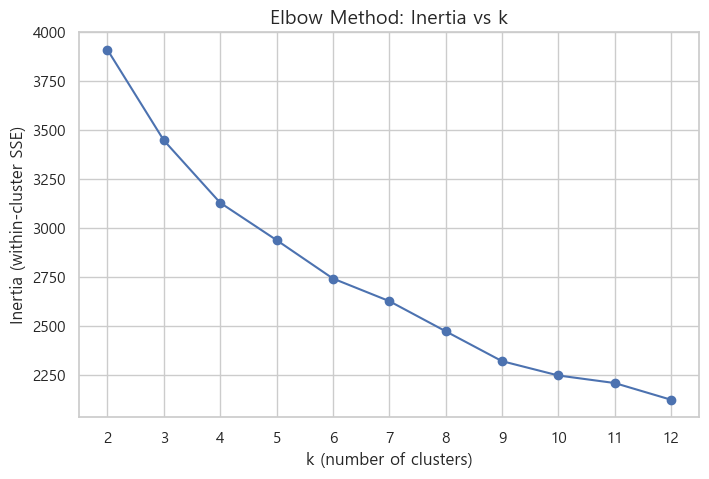

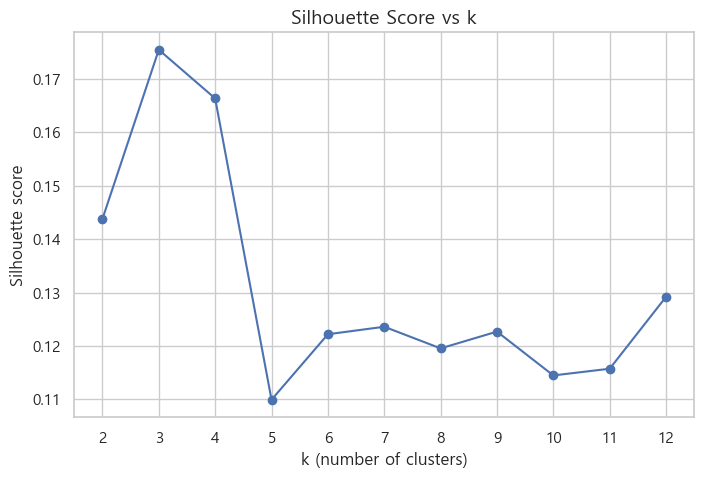

best_k (by silhouette): 3
cluster_kmeans
0     64
1    153
2     33
Name: count, dtype: int64


In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ============================================================
# 0) 입력: embed_df (index = 시장, columns = PCA/MCA components)
# ============================================================
# embed_df = ...  # 이미 만들어져 있다고 가정

# 결측/무한 처리
X = embed_df.replace([np.inf, -np.inf], np.nan).dropna(axis=0).copy()

# 스케일링 권장 (PCA/MCA 축이 섞여있어 분산 스케일이 다를 수 있음)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# ============================================================
# 1) K 범위 설정
# ============================================================
K_MIN = 2
K_MAX = 12  # 필요하면 15~20까지 늘려도 됨
random_state = 88

ks = list(range(K_MIN, K_MAX + 1))
inertias = []
silhouettes = []

# ============================================================
# 2) K별 inertia / silhouette 계산
# ============================================================
for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=20
    )
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)

    # silhouette는 k>=2에서만 정의되지만, k가 너무 크면 군집이 과도하게 쪼개져 값이 흔들릴 수 있음
    sil = silhouette_score(X_scaled, labels, metric="euclidean")
    silhouettes.append(sil)

# 결과 요약 테이블
score_df = pd.DataFrame({
    "k": ks,
    "inertia": inertias,
    "silhouette": silhouettes
}).sort_values("k")

print(score_df)

# ============================================================
# 3) 엘보우(inertia) 플롯
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(score_df["k"], score_df["inertia"], marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method: Inertia vs k")
plt.xticks(score_df["k"])
plt.grid(True)
plt.show()

# ============================================================
# 4) 실루엣 플롯
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(score_df["k"], score_df["silhouette"], marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.xticks(score_df["k"])
plt.grid(True)
plt.show()

# ============================================================
# 5) (선택) 실루엣 최대 k로 최종 모델 학습 + 라벨 부여
# ============================================================
best_k = score_df.loc[score_df["silhouette"].idxmax(), "k"]
print("best_k (by silhouette):", int(best_k))

final_km = KMeans(n_clusters=int(best_k), random_state=random_state, n_init=50)
final_labels = final_km.fit_predict(X_scaled)

# 원본 embed_df 인덱스 기준 라벨 시리즈
cluster_labels = pd.Series(final_labels, index=X.index, name="cluster_kmeans")

# 필요하면 embed_df에 붙이기
embed_df_kmeans = embed_df.copy()
embed_df_kmeans.loc[cluster_labels.index, "cluster_kmeans"] = cluster_labels

# 클러스터 크기 확인
print(cluster_labels.value_counts().sort_index())


In [171]:
tmp = embed_df_kmeans.copy()  # 이전 코드에서 cluster 붙인 df
tmp["cluster"] = tmp["cluster_kmeans"].astype(int)

# 클러스터별 임베딩 평균/표준편차
summary = tmp.groupby("cluster")[embed_df.columns].agg(["mean","std"])
display(summary)

# 클러스터별 각 컴포넌트 중앙값 비교(직관적)
median_diff = tmp.groupby("cluster")[embed_df.columns].median().T
median_diff["diff(0-1)"] = median_diff[0] - median_diff[1]
median_diff.sort_values("diff(0-1)", key=lambda s: s.abs(), ascending=False).head(15)


STRUCT_PC1           STRUCT_PC2           STRUCT_PC3            \
              mean       std       mean       std       mean       std   
cluster                                                                  
0        -0.042663  1.870655  -1.212722  1.127443   0.223157  0.982471   
1        -0.255063  1.560829   0.235069  0.913674  -0.003516  0.760492   
2         1.265307  1.866224   1.262080  0.820109  -0.416489  0.841318   

        ACCESS_PC1           ACCESS_PC2            ...  STAY_PC2            \
              mean       std       mean       std  ...      mean       std   
cluster                                            ...                       
0        -1.802203  0.569654   0.392695  0.649920  ... -0.857131  3.182262   
1         0.192169  1.032483  -0.302081  0.811682  ...  0.483428  0.358231   
2         2.604216  1.019164   0.638968  1.571638  ... -0.579031  0.602938   

         STAY_PC3               MCA_1               MCA_2               MCA_3  \
             mean       std      mean       std      mean       std      mean   
cluster                                                                         
0        1.122572  1.506884 -0.145780  0.322532 -0.063453  0.539359 -0.128558   
1       -0.266531  0.965386 -0.066829  0.583241 -0.008259  0.598882  0.045721   
2       -0.941373  1.171008  0.592569  1.018026  0.161354  0.702225  0.037346   

                   
              std  
cluster            
0        0.350289  
1        0.518309  
2        0.483863  

[3 rows x 36 columns]

cluster,0,1,2,diff(0-1)
OD_PC1,-2.686865,1.062683,1.201047,-3.749548
RESIDENT_PC1,1.843323,-0.655090,0.206457,2.498413
ACCESS_PC1,-1.907218,0.124754,2.858324,-2.031972
STAY_PC1,0.915739,-1.086906,2.612246,2.002645
STRUCT_PC2,-1.282832,0.324741,1.296453,-1.607573
STAY_PC3,1.211926,-0.235312,-0.541722,1.447238
STAY_PC2,-0.356191,0.509847,-0.345819,-0.866039
ACCESS_PC2,0.360269,-0.427138,0.199058,0.787408
OD_PC2,0.117724,0.625663,-2.130316,-0.507940
OD_PC3,-0.130616,0.288539,-0.392716,-0.419154


In [168]:
means = tmp.groupby("cluster")[embed_df.columns].mean().T
means["abs_gap"] = (means[0] - means[1]).abs()
means.sort_values("abs_gap", ascending=False).head(10)


cluster,0,1,2,3,abs_gap
OD_PC1,0.903297,-2.459142,-2.613300,1.193147,3.362439
RESIDENT_PC1,-0.832862,1.531474,1.840336,0.405202,2.364336
ACCESS_PC1,0.238810,-1.759680,-0.775117,2.539475,1.998490
STAY_PC1,-0.920871,0.886345,-6.661816,2.573509,1.807215
STRUCT_PC2,0.287692,-1.195360,-0.437905,1.181096,1.483052
STAY_PC3,-0.271672,1.054989,-0.963276,-0.886724,1.326661
STAY_PC2,0.504154,-0.264207,-18.284811,-0.560904,0.768361
OD_PC3,0.355875,-0.331883,0.147777,-0.873095,0.687758
ACCESS_PC2,-0.313399,0.315562,0.156435,0.705446,0.628961
RESIDENT_PC2,-0.089767,-0.526896,-0.821558,1.487589,0.437129


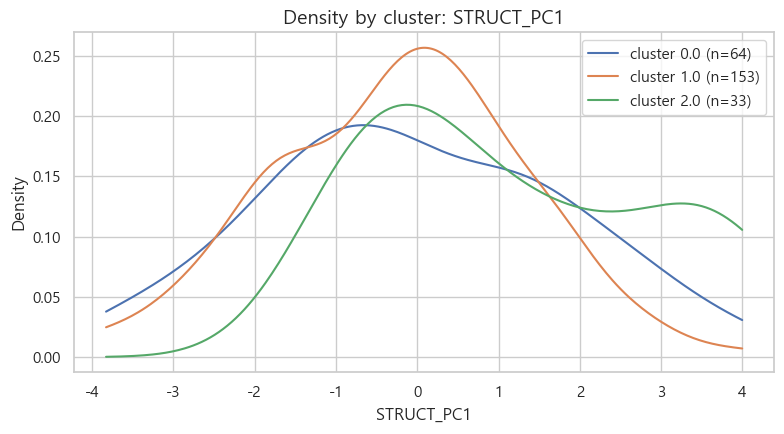

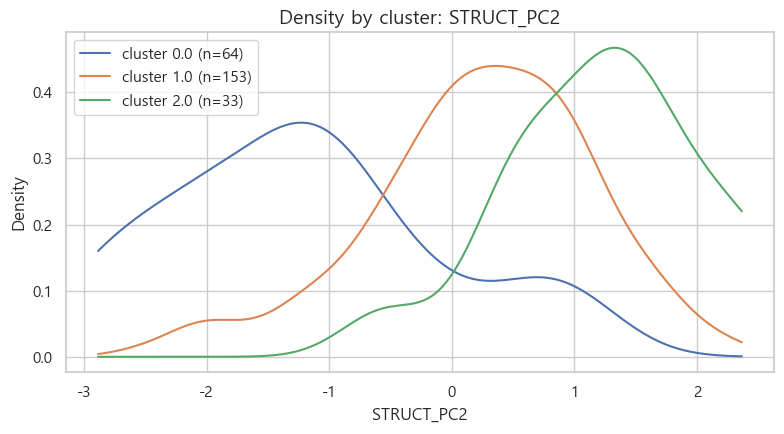

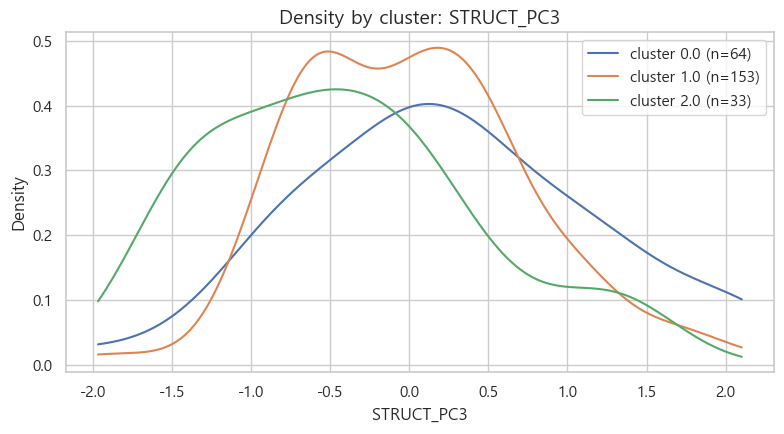

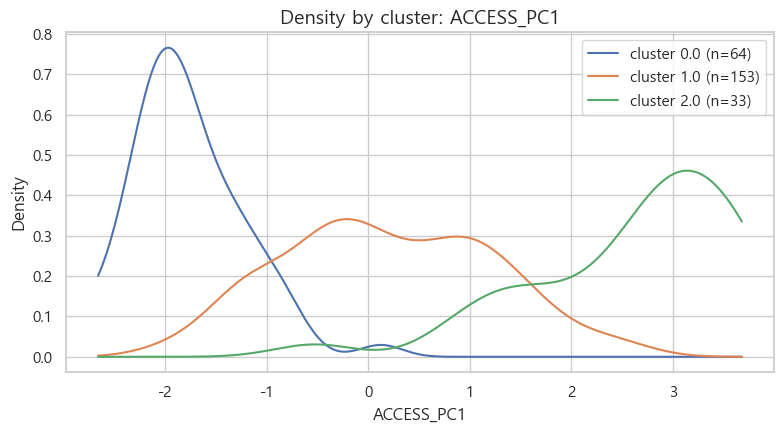

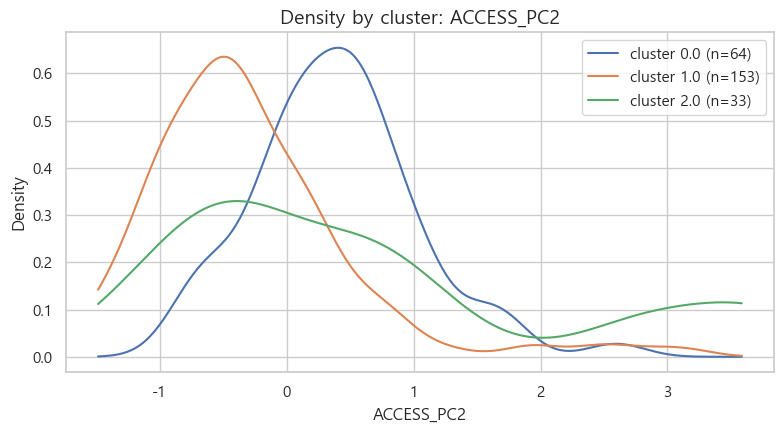

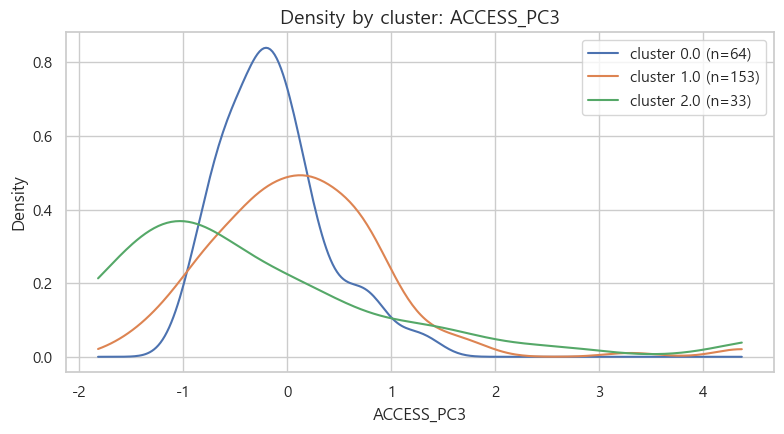

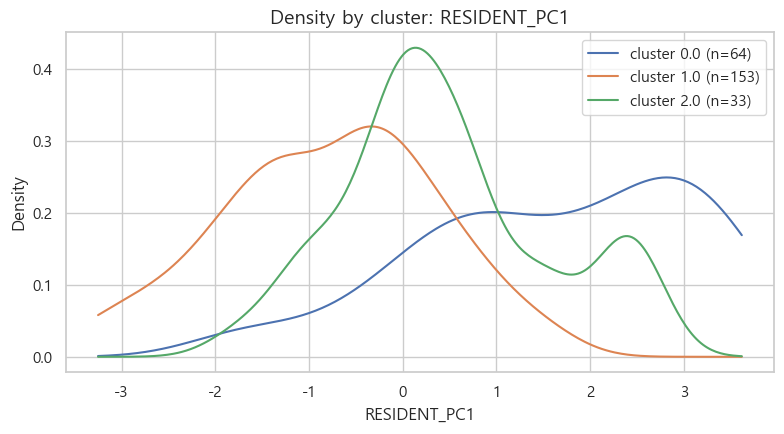

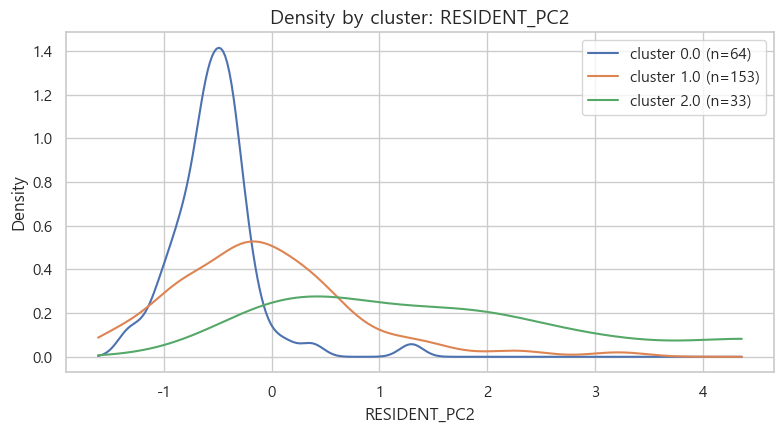

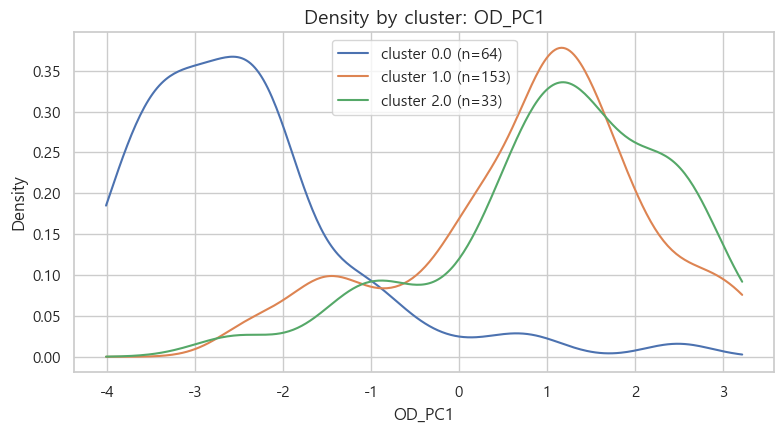

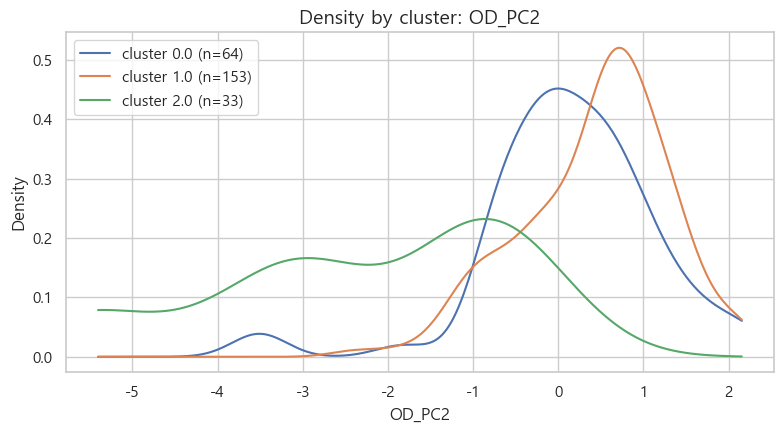

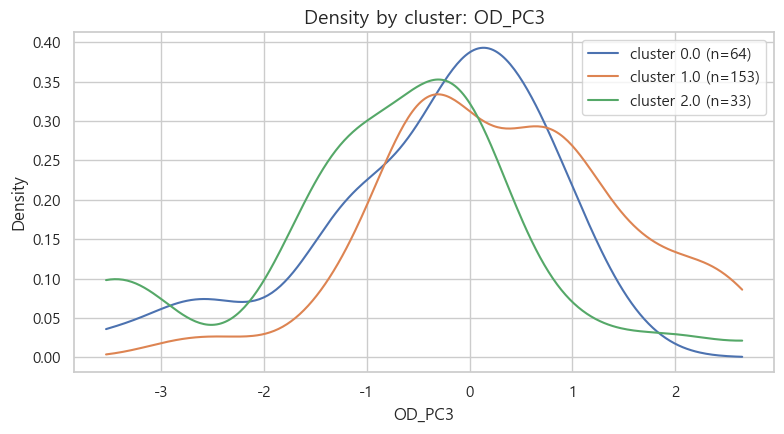

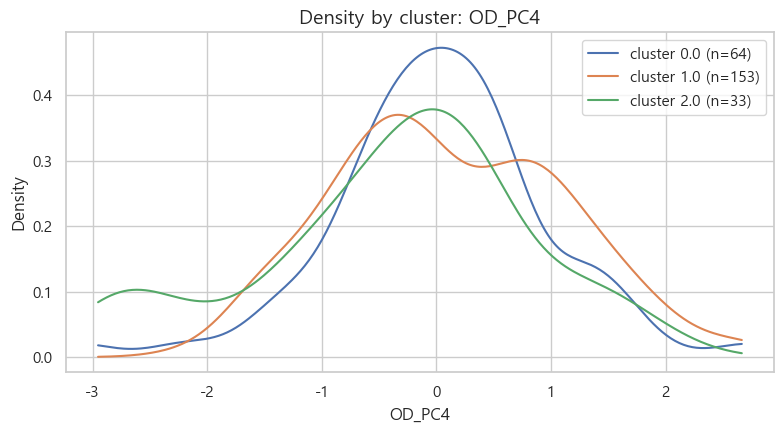

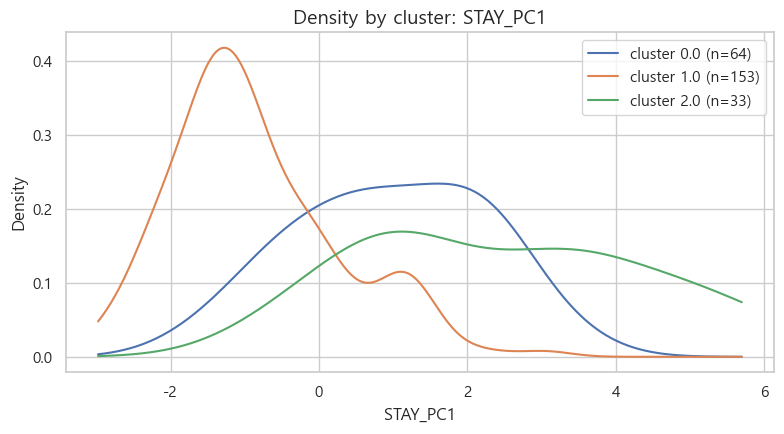

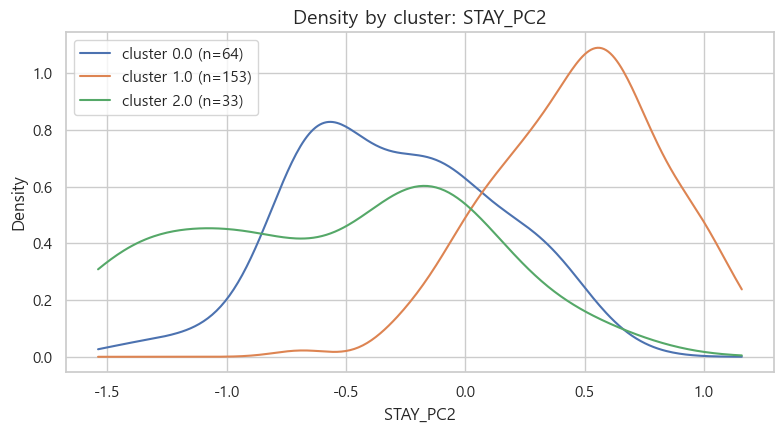

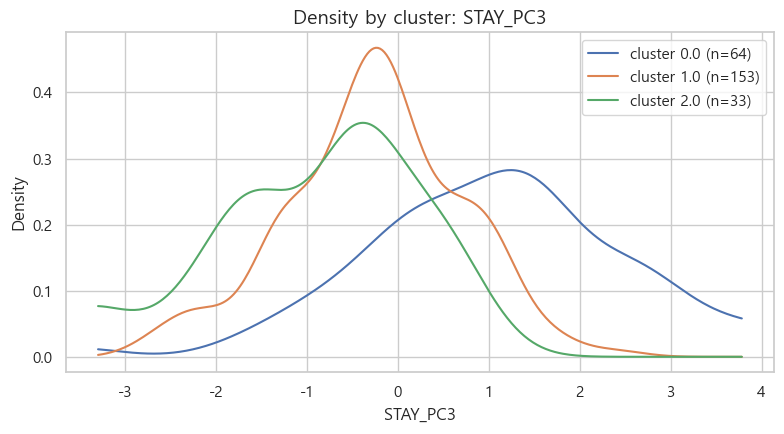

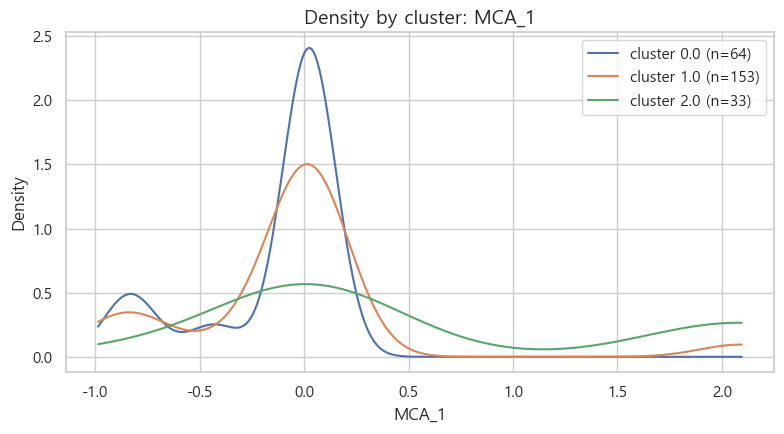

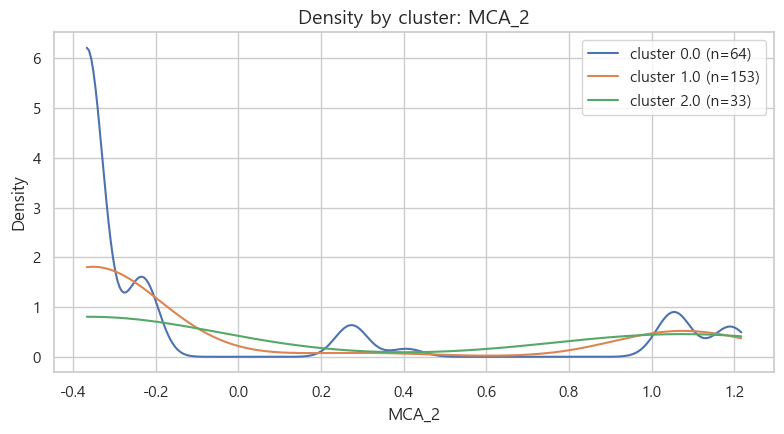

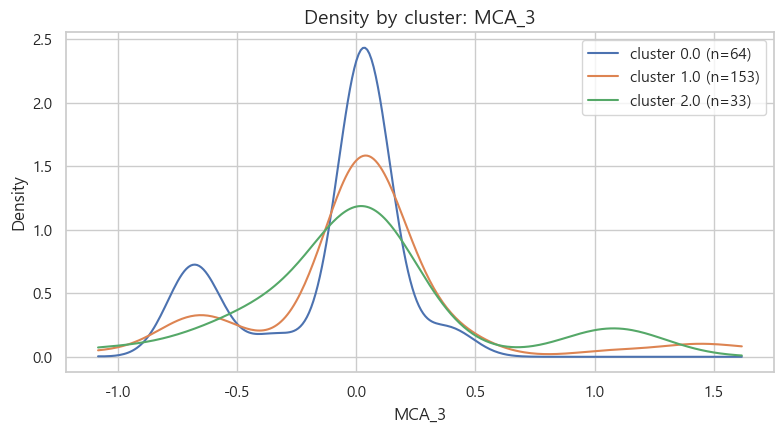

         feature       gap
3     ACCESS_PC1  4.406419
8         OD_PC1  3.653207
12      STAY_PC1  3.481676
9         OD_PC2  2.809456
1     STRUCT_PC2  2.474801
6   RESIDENT_PC1  2.444105
14      STAY_PC3  2.063945
7   RESIDENT_PC2  2.060455
0     STRUCT_PC1  1.520370
13      STAY_PC2  1.340559
10        OD_PC3  1.146514
4     ACCESS_PC2  0.941050
15         MCA_1  0.738349
2     STRUCT_PC3  0.639645
11        OD_PC4  0.326268


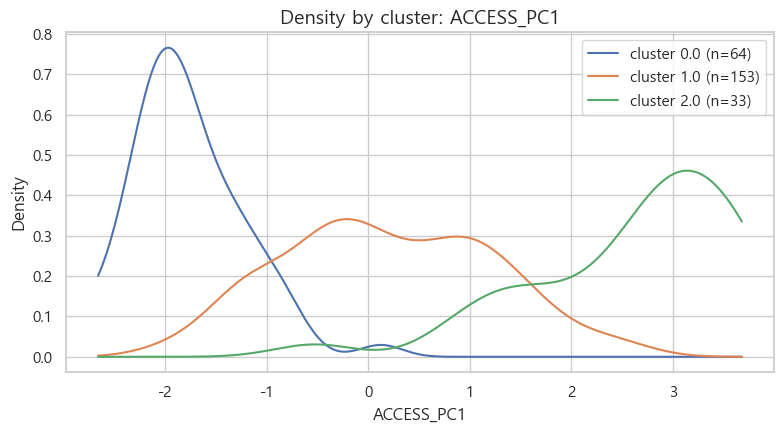

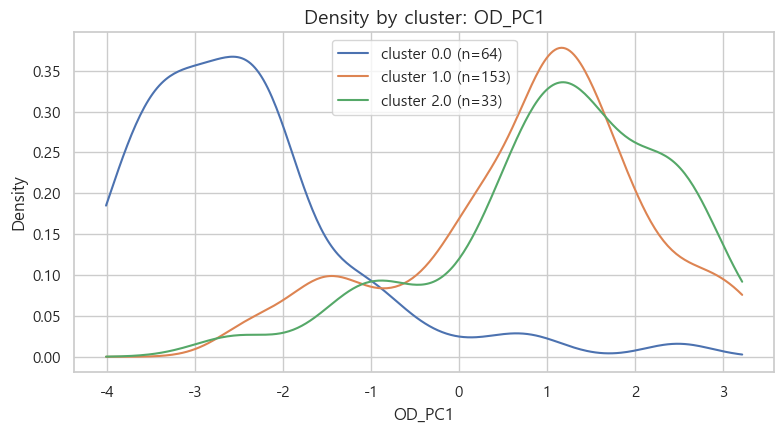

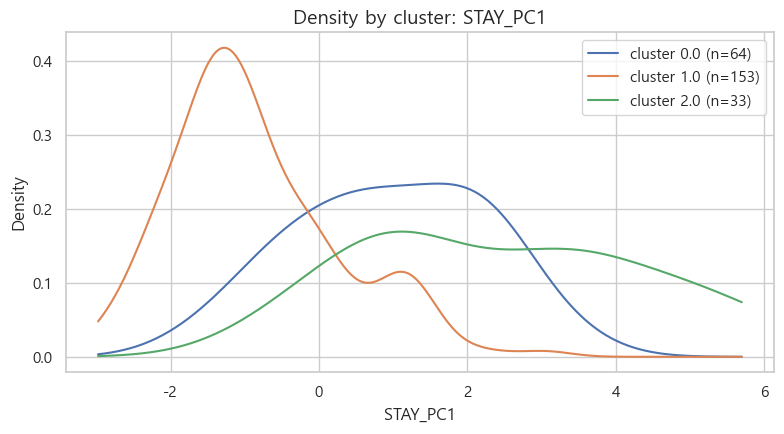

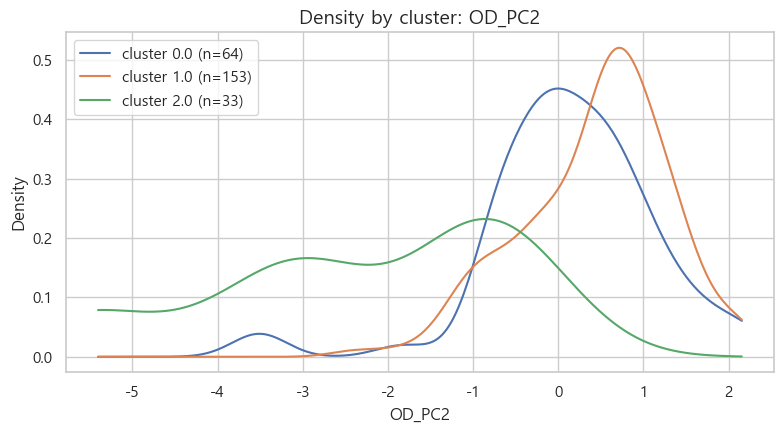

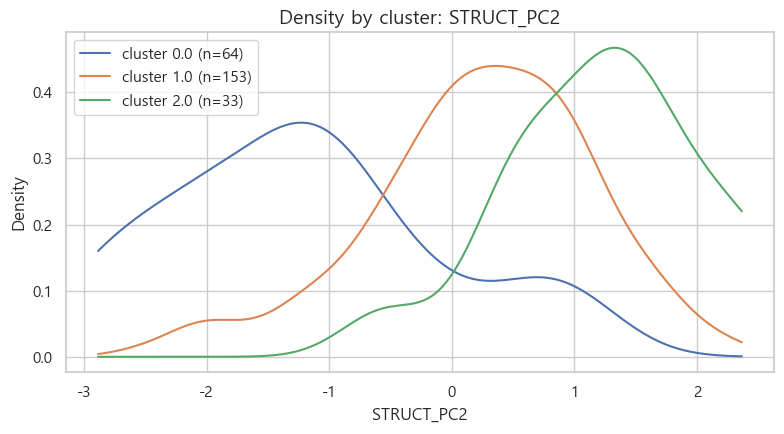

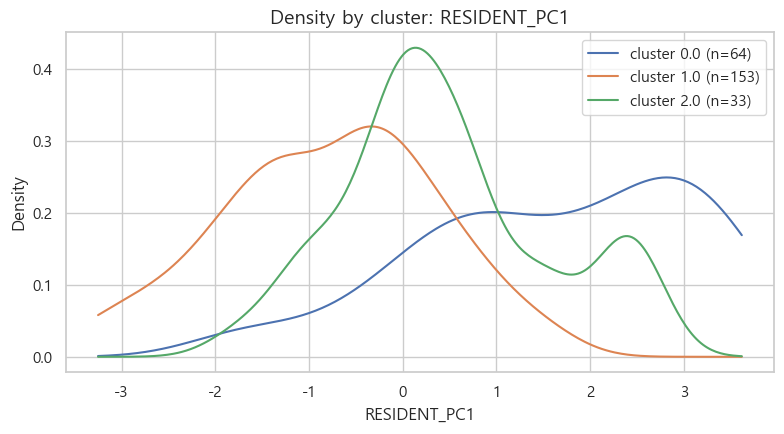

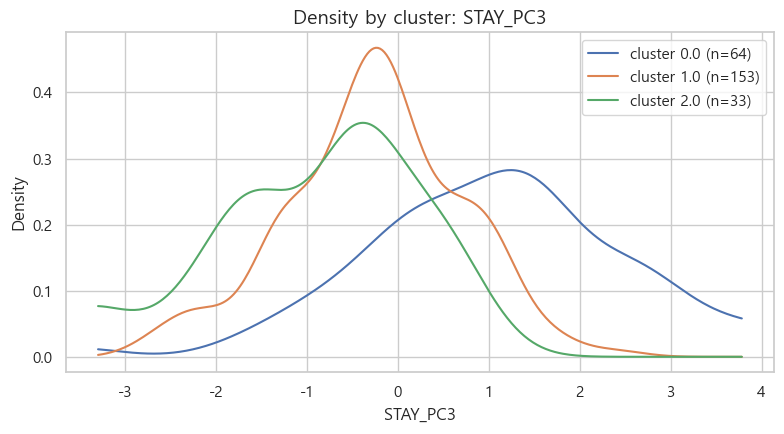

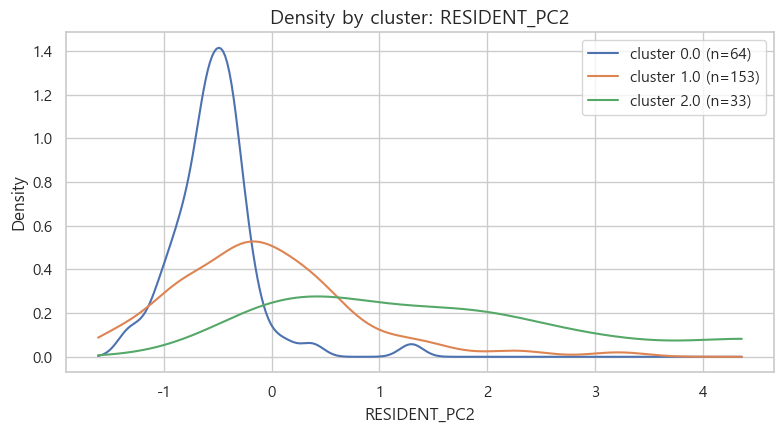

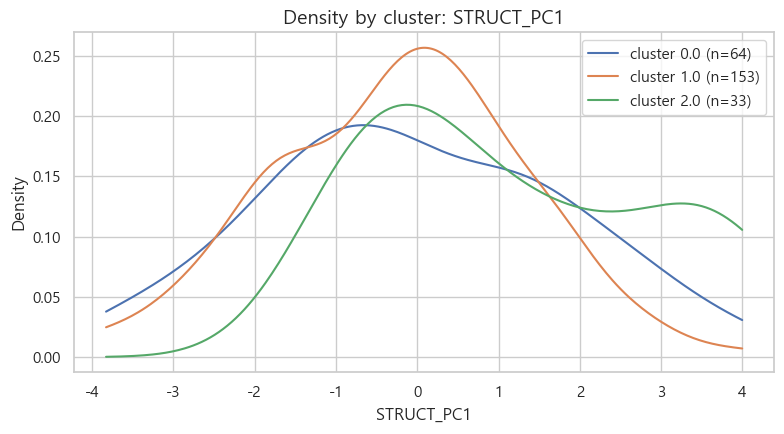

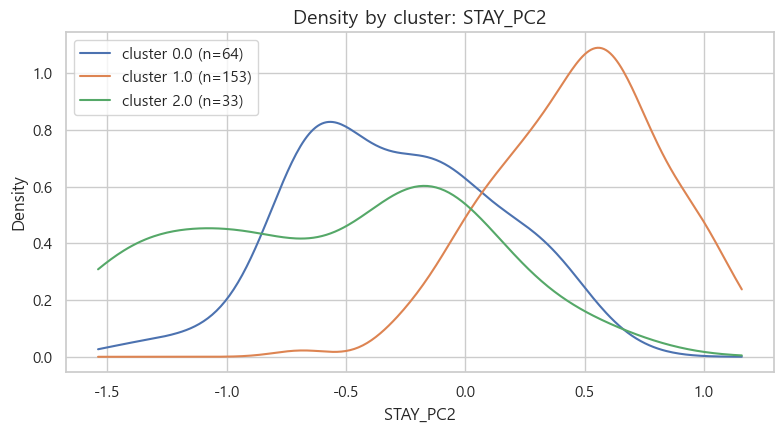

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# density plot (KDE) without seaborn
# - 각 PC/MCA 축별로 cluster별 분포를 겹쳐서 그림
# - matplotlib만 사용
# ------------------------------------------------------------

# 0) 입력: embed_df_kmeans (PC/MCA + cluster_kmeans 컬럼 포함)
dfp = embed_df_kmeans.copy()
cluster_col = "cluster_kmeans"

# PC/MCA 컬럼만 자동 탐지 (cluster 컬럼 제외)
embed_cols = [c for c in dfp.columns if c != cluster_col]

# 결측/무한 처리
dfp = dfp.replace([np.inf, -np.inf], np.nan)
dfp = dfp.dropna(subset=embed_cols + [cluster_col])

# 클러스터 목록
clusters = sorted(dfp[cluster_col].dropna().unique().tolist())

# ------------------------------------------------------------
# 1) 간단 KDE 구현 (Gaussian kernel)
# ------------------------------------------------------------
def kde_gaussian_1d(x, grid, bw=None):
    """
    x: 1D array
    grid: evaluation points
    bw: bandwidth. None이면 Silverman rule로 자동.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    if n < 2:
        return np.zeros_like(grid)

    # Silverman bandwidth
    if bw is None:
        std = np.std(x, ddof=1)
        iqr = np.subtract(*np.percentile(x, [75, 25]))
        sigma = min(std, iqr / 1.34) if iqr > 0 else std
        bw = 0.9 * sigma * (n ** (-1/5))
        if bw <= 0 or np.isnan(bw):
            bw = 1.0

    diff = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bw * np.sqrt(2*np.pi))
    return dens

# ------------------------------------------------------------
# 2) 축별 density plot 그리기
# ------------------------------------------------------------
def plot_density_by_cluster(
    df,
    feature,
    cluster_col="cluster_kmeans",
    gridsize=300,
    bw=None,
    xlim=None
):
    # 전체 범위 기준 grid
    x_all = df[feature].to_numpy(dtype=float)
    x_all = x_all[~np.isnan(x_all)]

    if x_all.size < 2:
        print(f"[SKIP] {feature}: not enough data")
        return

    if xlim is None:
        lo, hi = np.percentile(x_all, [1, 99])
        if lo == hi:
            lo, hi = x_all.min(), x_all.max()
            if lo == hi:
                lo, hi = lo - 1, hi + 1
    else:
        lo, hi = xlim

    grid = np.linspace(lo, hi, gridsize)

    plt.figure(figsize=(8, 4.5))

    for cl in sorted(df[cluster_col].unique()):
        x = df.loc[df[cluster_col] == cl, feature].to_numpy(dtype=float)
        dens = kde_gaussian_1d(x, grid, bw=bw)
        plt.plot(grid, dens, label=f"cluster {cl} (n={len(x)})")

    plt.title(f"Density by cluster: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 3) 전체 PC/MCA에 대해 일괄 출력
#    - 너무 많으면 상위 몇 개만 선택하거나 loop에서 break
# ------------------------------------------------------------

# 예: 모든 임베딩 축에 대해 순차적으로 그림
for col in embed_cols:
    plot_density_by_cluster(dfp, col, cluster_col=cluster_col)

# ------------------------------------------------------------
# 4) (선택) "클러스터 평균 차이 큰 축 TOP N"만 그리기
# ------------------------------------------------------------
def top_gap_features(df, embed_cols, cluster_col="cluster_kmeans", top_n=10):
    means = df.groupby(cluster_col)[embed_cols].mean().T
    if means.shape[1] != 2:
        # 클러스터가 2개일 때만 abs_gap 단순 계산
        # 그 외는 max-min로 갭 정의
        gap = means.max(axis=1) - means.min(axis=1)
    else:
        cols = means.columns.tolist()
        gap = (means[cols[0]] - means[cols[1]]).abs()

    out = pd.DataFrame({"feature": gap.index, "gap": gap.values}).sort_values("gap", ascending=False)
    return out.head(top_n)["feature"].tolist(), out

top_feats, gap_df = top_gap_features(dfp, embed_cols, cluster_col=cluster_col, top_n=10)
print(gap_df.head(15))

for col in top_feats:
    plot_density_by_cluster(dfp, col, cluster_col=cluster_col)


In [173]:
top_feats

['ACCESS_PC1',
 'OD_PC1',
 'STAY_PC1',
 'OD_PC2',
 'STRUCT_PC2',
 'RESIDENT_PC1',
 'STAY_PC3',
 'RESIDENT_PC2',
 'STRUCT_PC1',
 'STAY_PC2']

In [174]:
gap_df

,feature,gap
3,ACCESS_PC1,4.406419
8,OD_PC1,3.653207
12,STAY_PC1,3.481676
9,OD_PC2,2.809456
1,STRUCT_PC2,2.474801
6,RESIDENT_PC1,2.444105
14,STAY_PC3,2.063945
7,RESIDENT_PC2,2.060455
0,STRUCT_PC1,1.520370
13,STAY_PC2,1.340559


## PCA

In [136]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import prince

In [137]:
# 원핫으로 존재하는 market_item_type 더미들
market_item_dummies = [
    'market_item_type_먹거리/외식형',
    'market_item_type_복합형(생활+비식품)',
    'market_item_type_비식품/전문형',
    'market_item_type_생활형(장보기형)',
    'market_item_type_서비스형'
]

# 변수 묶음(사용자가 준 정의를 그대로 반영)
struct_vars = [
    '시장면적','전체점포','노점수','총시장상인','편의시설수',
    '점포_대_상인_비율','has_assoc','join_stores'
]

sales_vars = [
    'item_diversity','is_food_based','has_nonfood','delivery_grocery','market_item_type'
]

resident_vars = ['pop_adole','pop_young','pop_middle','pop_senior']

od_vars = [
    'od_adole','od_young','od_middle','od_senior','od_consumption','od_workedu',
    'od_residential','od_in_weekday','od_in_holiday','od_modal_car','od_modal_walk',
    'od_modal_bus','od_modal_sub','od_modal_etc'
]

stay_vars = [
    'stay_adole','stay_young','stay_middle','stay_senior','stay_consumption','stay_workedu',
    'stay_residential','stay_weekday','stay_holiday','stay_morning','stay_lunch','stay_evening','stay_night'
]

access_vars = ['parking','bus','mart','tour','conv','subway']

#policy_vars = ['지원여부']
target = '빈점포율'

In [138]:
def restore_market_item_type(df: pd.DataFrame,
                             dummy_cols: list,
                             new_col: str = "market_item_type",
                             unknown_label: str = "미분류") -> pd.DataFrame:
    """
    원핫 더미들에서 가장 큰 값을 갖는 컬럼명을 new_col로 복원.
    - 정상적으로는 0/1이며 1인 컬럼이 하나여야 함
    - 모두 0이거나 결측이면 unknown_label
    """
    df = df.copy()

    # 존재하는 더미만 사용
    dummy_cols_exist = [c for c in dummy_cols if c in df.columns]
    if len(dummy_cols_exist) == 0:
        # 이미 market_item_type이 존재하는 경우 그냥 리턴
        if new_col in df.columns:
            return df
        raise ValueError("market_item_type 더미 컬럼이 df에 없습니다.")

    # 행별 최대 더미 선택
    dummy_mat = df[dummy_cols_exist].fillna(0)

    # 모두 0인 경우 처리
    row_sum = dummy_mat.sum(axis=1)
    argmax_col = dummy_mat.idxmax(axis=1)

    # 컬럼명에서 prefix 제거하여 라벨 복원
    labels = argmax_col.str.replace("market_item_type_", "", regex=False)
    labels = labels.where(row_sum > 0, other=unknown_label)

    df[new_col] = labels

    # 더미 컬럼 제거(선택)
    df.drop(columns=dummy_cols_exist, inplace=True, errors="ignore")

    return df


df_od_2 = restore_market_item_type(df_od, market_item_dummies, new_col="market_item_type")

In [139]:
# 이진형 + 범주형: MCA
mca_cols = [
    'market_item_type',      # 범주형
    'is_food_based',         # 이진형
    'has_nonfood',           # 이진형
    'delivery_grocery',      # 이진형
    'has_assoc'              # 이진형(사실 구조 변수지만 MCA쪽이 자연스러움)
    #'지원여부'                # 이진형(정책 변수)
]

# PCA 대상: 숫자 연속형(카운트/비율 포함)
# - 여기서는 위 mca_cols를 제외한 나머지 수치형 변수들을 PCA에 태움
all_features = (
    struct_vars
    + sales_vars
    + resident_vars
    + od_vars
    + stay_vars
    + access_vars
    #+ policy_vars
)

In [140]:
pca_cols = [c for c in all_features if c not in mca_cols and c != target]
pca_cols = [c for c in pca_cols if c in df_od_2.columns]
mca_cols = [c for c in mca_cols if c in df_od_2.columns]

In [141]:
# PCA: 결측을 중앙값으로 대체 (원하면 fancyimpute 등으로 확장)
#df_work = df_od_2.copy()
#for c in pca_cols:
#    df_work[c] = pd.to_numeric(df_work[c], errors="coerce")
#    df_work[c] = df_work[c].fillna(df_work[c].median())

# MCA: 결측을 '미분류'로 대체
#for c in mca_cols:
#    if df_work[c].dtype.kind in "biufc":
#        # 이진형이 numeric이면 문자열로 변환(0/1 -> '0'/'1')하는 게 MCA에 안전
#        df_work[c] = df_work[c].fillna(0).astype(int).astype(str)
#    else:
#        df_work[c] = df_work[c].fillna("미분류").astype(str)



In [142]:
n_pca = 12  # 필요시 조절
pca_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_pca, random_state=88))
])

X_pca = pca_pipe.fit_transform(df_od_2[pca_cols])

pca_names = [f"PCA_{i+1}" for i in range(n_pca)]
pca_df = pd.DataFrame(X_pca, columns=pca_names, index=df_od_2.index)

# PCA 로딩(해석용)
pca_loadings = pd.DataFrame(
    pca_pipe.named_steps["pca"].components_.T,
    index=pca_cols,
    columns=pca_names
)

explained_var = pca_pipe.named_steps["pca"].explained_variance_ratio_
explained_var_df = pd.DataFrame({"component": pca_names, "explained_ratio": explained_var})

In [143]:
pca_loadings

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12
시장면적,-0.004392,0.003427,0.170414,0.420720,-0.040526,-0.116350,0.075670,0.225995,0.231412,-0.132885,0.100346,0.073668
전체점포,0.001615,0.129551,0.365058,0.307554,-0.139021,-0.174268,0.201137,0.067269,0.130057,0.098257,0.003190,-0.003068
노점수,-0.013380,-0.054624,0.068595,0.313076,0.217314,0.248875,-0.396520,-0.059833,-0.102606,-0.108752,0.338419,0.002138
총시장상인,0.002928,0.102679,0.332739,0.329087,-0.133295,-0.216101,0.120203,0.149290,0.073243,0.123123,0.103535,0.035494
편의시설수,0.024340,0.042135,0.173902,0.198563,-0.089257,0.422394,-0.083754,-0.203195,-0.012614,-0.350219,-0.445265,-0.099433
점포_대_상인_비율,0.000599,0.069618,-0.076539,-0.289519,-0.090523,-0.013429,0.479569,-0.038319,0.418074,-0.104849,-0.235970,0.143581
join_stores,0.004699,0.112765,0.287721,0.156889,-0.087534,0.185927,0.062847,-0.256954,-0.015017,0.057728,-0.313994,-0.098504
item_diversity,0.002945,-0.066998,-0.105730,0.108865,-0.050495,0.287887,-0.263001,-0.257750,0.516159,0.567364,-0.090400,0.122556
pop_adole,0.152773,-0.253861,0.046159,0.002387,-0.023851,0.047460,0.122628,0.030755,-0.054956,0.014268,0.045609,-0.133672
pop_young,0.155484,-0.216547,0.116146,-0.107527,-0.101704,0.024965,-0.034857,0.137416,-0.020893,-0.031612,-0.048108,-0.035933


In [144]:
n_mca = 3  # 필요시 조절

mca = prince.MCA(
    n_components=n_mca,
    n_iter=5,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=88
)

X_mca = mca.fit_transform(df_od_2[mca_cols])

mca_names = [f"MCA_{i+1}" for i in range(n_mca)]
mca_df = pd.DataFrame(X_mca.values, columns=mca_names, index=df_od_2.index)

# MCA 설명력(가능하면 보고서에)
# prince는 eigenvalues_, percentage_of_variance_ 등 제공(버전에 따라 다를 수 있음)
mca_info = {}
if hasattr(mca, "percentage_of_variance_"):
    mca_info["percentage_of_variance_"] = mca.percentage_of_variance_
if hasattr(mca, "eigenvalues_"):
    mca_info["eigenvalues_"] = mca.eigenvalues_

In [145]:
# ============================================================
# PCA (연속형) + MCA (범주형/이진형) 혼합 차원축소 템플릿
# - market_item_type 원핫 -> 단일 범주형으로 복원
# - 연속형: StandardScaler + PCA
# - 범주/이진형: OneHotEncoder + MCA
# - (선택) 두 임베딩 결합하여 최종 feature로 사용
# ============================================================





# -----------------------------
# 6) (선택) PCA + MCA 결합 임베딩
# -----------------------------
embed_df = pd.concat([pca_df, mca_df], axis=1)

# 필요하면 원본 df에 붙이기
df_embed = pd.concat([df_od_2, embed_df], axis=1)

print("PCA columns:", pca_cols[:10], "...", len(pca_cols))
print("MCA columns:", mca_cols)
print("Embedding shape:", embed_df.shape)
print("\nPCA explained variance ratio:\n", explained_var_df)

# 로딩/해석 테이블은 아래를 참고
# pca_loadings.sort_values("PCA_1", key=np.abs, ascending=False).head(20)
# df_embed.head()


PCA columns: ['시장면적', '전체점포', '노점수', '총시장상인', '편의시설수', '점포_대_상인_비율', 'join_stores', 'item_diversity', 'pop_adole', 'pop_young'] ... 45
MCA columns: ['market_item_type', 'is_food_based', 'has_nonfood', 'delivery_grocery', 'has_assoc']
Embedding shape: (833, 15)

PCA explained variance ratio:
    component  explained_ratio
0      PCA_1         0.439292
1      PCA_2         0.118220
2      PCA_3         0.079234
3      PCA_4         0.050127
4      PCA_5         0.035234
5      PCA_6         0.030468
6      PCA_7         0.028660
7      PCA_8         0.024283
8      PCA_9         0.021948
9     PCA_10         0.018861
10    PCA_11         0.016543
11    PCA_12         0.016269


## Median 차이

In [8]:
STRUCT_COLS = [
    "시장면적", "전체점포", "노점수", "점포상인", '노점상인'
    "종업원", "편의시설수",
]

META_COLS = [
    'parking', 'bus', 'mart',
    'subway', 'tour',
    "pop_adole", "pop_young", "pop_middle", "pop_senior"
]

CONTENT_COLS = [
    "is_food_based", "delivery_grocery",
    "has_assoc", "item_diversity"
]


POP_COLS = [
    "pop_adole", "pop_young", "pop_middle", "pop_senior"
]


OD_COLS = [
    "od_consumption", "od_residential", 'od_workedu',
    "od_in_weekday", "od_in_holiday",
     'od_modal_car', 'od_modal_walk', 'od_modal_bus', 
     'od_modal_sub', 'od_modal_etc'
]


STAY_COLS = [
    "stay_consumption", "stay_residential", 'stay_workedu',
    "stay_weekday", "stay_holiday",
    'stay_holiday', 'stay_morning', 'stay_lunch', 'stay_evening'
]


In [9]:
RATIO_GROUPS = {
    # 주민등록 인구 구성비
    "pop": ["pop_adole", "pop_young", "pop_middle", "pop_senior"],

    # OD: 연령 구성비
    "od_age": ["od_adole", "od_young", "od_middle", "od_senior"],

    # OD: 목적 구성비
    "od_purpose": ["od_residential", "od_workedu", "od_consumption"],

    # OD: 요일 구성비
    "od_daytype": ["od_in_weekday", "od_in_holiday"],

    # OD: 이동수단 구성비
    "od_modal": ["od_modal_car", "od_modal_walk", "od_modal_bus", "od_modal_sub", "od_modal_etc"],

    # Stay: 연령 구성비
    "stay_age": ["stay_adole", "stay_young", "stay_middle", "stay_senior"],

    # Stay: 목적 구성비
    "stay_purpose": ["stay_residential", "stay_workedu", "stay_consumption"],

    # Stay: 요일 구성비
    "stay_daytype": ["stay_weekday", "stay_holiday"],

    # Stay: 시간대 구성비
    "stay_time": ["stay_morning", "stay_lunch", "stay_evening", "stay_night"],
}


In [10]:
import numpy as np
import pandas as pd

def add_ratio_features(df: pd.DataFrame, ratio_groups: dict, eps: float = 1e-9) -> pd.DataFrame:
    df2 = df.copy()

    for gname, cols in ratio_groups.items():
        # 존재하는 컬럼만 사용(방어)
        cols = [c for c in cols if c in df2.columns]
        if len(cols) <= 1:
            continue

        denom = df2[cols].sum(axis=1).replace(0, np.nan)  # 0이면 NaN 처리
        for c in cols:
            new_c = f"{c}_ratio"
            df2[new_c] = df2[c] / (denom + eps)

    return df2


In [11]:
df_high_r = add_ratio_features(df_high, RATIO_GROUPS)
df_low_r  = add_ratio_features(df_low,  RATIO_GROUPS)


In [12]:
ratio_cols = []
for cols in RATIO_GROUPS.values():
    ratio_cols += [f"{c}_ratio" for c in cols]
ratio_cols = [c for c in ratio_cols if c in df_high_r.columns]


In [13]:
BASE_COLS = STRUCT_COLS + META_COLS + CONTENT_COLS   # 원값 비교(원하는대로 수정 가능)

COMPARE_COLS = BASE_COLS + ratio_cols


In [16]:
def compare_median(df_high, df_low, cols):
    cols = [c for c in cols if c in df_high.columns and c in df_low.columns]
    out = pd.DataFrame({
        "High_Risk_Median": df_high[cols].median(),
        "Low_Risk_Median": df_low[cols].median(),
    })
    out["Diff"] = out["High_Risk_Median"] - out["Low_Risk_Median"]
    return out.sort_values("Diff", ascending=False)


In [40]:
CP_COLS = ['시장면적', '전체점포', '노점수',
       '총시장상인', '편의시설수', '점포_대_상인_비율', 'parking', 'bus', 'mart', 'tour',
       'conv', 'subway', 'pop_adole', 'pop_young', 'pop_middle', 'pop_senior',
       '지원여부', 'has_assoc', 'join_stores', 'item_diversity', 'is_food_based',
       'has_nonfood', 'delivery_grocery', '빈점포율', 'od_adole', 'od_young',
       'od_middle', 'od_senior', 'od_consumption', 'od_workedu',
       'od_residential', 'od_in_weekday', 'od_in_holiday', 'od_modal_car',
       'od_modal_walk', 'od_modal_bus', 'od_modal_sub', 'od_modal_etc',
       'stay_adole', 'stay_young', 'stay_middle', 'stay_senior',
       'stay_consumption', 'stay_workedu', 'stay_residential', 'stay_weekday',
       'stay_holiday', 'stay_morning', 'stay_lunch', 'stay_evening',
       'stay_night', 'market_item_type_먹거리/외식형',
       'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형',
       'market_item_type_생활형(장보기형)', 'market_item_type_서비스형']

In [41]:
compare_median(df_high_r, df_low_r, CP_COLS)

,High_Risk_Median,Low_Risk_Median,Diff
stay_senior,2.309364e+06,2.293497e+06,15866.500000
od_consumption,3.229000e+04,2.628600e+04,6004.000000
od_workedu,2.679500e+04,2.191900e+04,4876.000000
od_modal_bus,2.040300e+04,1.807100e+04,2332.000000
pop_senior,4.430500e+03,4.209000e+03,221.500000
od_modal_sub,6.960000e+02,5.810000e+02,115.000000
bus,1.800000e+01,1.550000e+01,2.500000
빈점포율,2.138095e-01,0.000000e+00,0.213810
점포_대_상인_비율,7.207168e-01,6.649396e-01,0.055777
has_nonfood,1.000000e+00,1.000000e+00,0.000000


In [17]:
result = compare_median(df_high_r, df_low_r, COMPARE_COLS)
#result.head(30)


In [18]:
# 1) 구조/메타/콘텐츠(원값)
compare_median(df_high_r, df_low_r, BASE_COLS).sort_values('Diff', ascending=True)


,High_Risk_Median,Low_Risk_Median,Diff
시장면적,4030.0,5234.5,-1204.5
pop_young,2609.0,3407.5,-798.5
pop_middle,3735.0,4274.5,-539.5
pop_adole,872.0,992.5,-120.5
노점수,3.0,5.0,-2.0
parking,2.0,3.0,-1.0
item_diversity,6.0,7.0,-1.0
편의시설수,9.0,10.0,-1.0
전체점포,80.0,80.0,0.0
tour,1.0,1.0,0.0


In [19]:
# 2) 주민등록 인구 구성비
compare_median(df_high_r, df_low_r, [f"{c}_ratio" for c in RATIO_GROUPS["pop"]])

,High_Risk_Median,Low_Risk_Median,Diff
pop_senior_ratio,0.369553,0.330693,0.038860
pop_adole_ratio,0.067754,0.066628,0.001127
pop_middle_ratio,0.315762,0.322284,-0.006522
pop_young_ratio,0.222964,0.241135,-0.018171


In [20]:
# 3) OD 구성비(목적/요일/이동수단/연령)
compare_median(df_high_r, df_low_r, 
              [f"{c}_ratio" for c in (RATIO_GROUPS["od_purpose"] + RATIO_GROUPS["od_daytype"] + RATIO_GROUPS["od_modal"] + RATIO_GROUPS["od_age"])]
             ).sort_values('Diff', ascending=True)

,High_Risk_Median,Low_Risk_Median,Diff
od_residential_ratio,0.736149,0.769272,-0.033123
od_adole_ratio,0.326987,0.356431,-0.029444
od_modal_etc_ratio,0.096044,0.117335,-0.021291
od_middle_ratio,0.239838,0.247157,-0.007319
od_in_weekday_ratio,0.608350,0.613813,-0.005463
od_senior_ratio,0.037595,0.039556,-0.001962
od_modal_walk_ratio,0.010913,0.012624,-0.001712
od_modal_sub_ratio,0.002689,0.001883,0.000807
od_consumption_ratio,0.123720,0.120442,0.003278
od_in_holiday_ratio,0.391650,0.386187,0.005463


In [21]:
# 4) Stay 구성비(목적/요일/시간대/연령)
compare_median(df_high_r, df_low_r, 
              [f"{c}_ratio" for c in (RATIO_GROUPS["stay_purpose"] + RATIO_GROUPS["stay_daytype"] + RATIO_GROUPS["stay_time"] + RATIO_GROUPS["stay_age"])]
             ).sort_values('Diff', ascending=True)

,High_Risk_Median,Low_Risk_Median,Diff
stay_residential_ratio,0.793072,0.809714,-0.016641
stay_night_ratio,0.239371,0.248328,-0.008957
stay_adole_ratio,0.165059,0.173770,-0.008711
stay_middle_ratio,0.335806,0.337875,-0.002069
stay_holiday_ratio,0.424262,0.425879,-0.001617
stay_consumption_ratio,0.089070,0.088909,0.000161
stay_evening_ratio,0.250382,0.249997,0.000385
stay_weekday_ratio,0.575738,0.574121,0.001617
stay_senior_ratio,0.218411,0.215741,0.002670
stay_morning_ratio,0.253767,0.251002,0.002765


## 시각화 비교?

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

plt.rcParams["font.family"] = "Malgun Gothic"  # Windows
plt.rcParams["axes.unicode_minus"] = False



def prep_compare_df(df_high, df_low, cols, stat="median", group_names=("High", "Low"), value_name="Value"):
    if stat == "median":
        s_high = df_high[cols].median()
        s_low  = df_low[cols].median()
    elif stat == "mean":
        s_high = df_high[cols].mean()
        s_low  = df_low[cols].mean()
    else:
        raise ValueError("stat must be 'median' or 'mean'")

    out = (pd.DataFrame({group_names[0]: s_high, group_names[1]: s_low})
             .reset_index()
             .rename(columns={"index": "Feature"})
             .melt(id_vars="Feature", var_name="Group", value_name=value_name))
    return out

def barplot_compare(plot_df, title, y_col="Value", x_col="Feature", hue_col="Group",
                    figsize=(9,4), rotate=35, show_value=True, value_fmt="{:.2f}",
                    sort_by=None):
    d = plot_df.copy()

    # 정렬 옵션: High 기준, Low 기준, 또는 전체 평균 기준
    if sort_by in ["High", "Low"]:
        order = (d[d["Group"] == sort_by]
                 .sort_values(y_col, ascending=False)[x_col].tolist())
        d[x_col] = pd.Categorical(d[x_col], categories=order, ordered=True)
        d = d.sort_values(x_col)
    elif sort_by == "mean":
        order = (d.groupby(x_col)[y_col].mean().sort_values(ascending=False).index.tolist())
        d[x_col] = pd.Categorical(d[x_col], categories=order, ordered=True)
        d = d.sort_values(x_col)

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=d, x=x_col, y=y_col, hue=hue_col, ax=ax, errorbar=None)

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(y_col)
    ax.tick_params(axis="x", rotation=rotate)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_value:
        # seaborn bar 컨테이너 단위로 값 표기
        for container in ax.containers:
            labels = []
            for v in container.datavalues:
                if pd.isna(v):
                    labels.append("")
                else:
                    labels.append(value_fmt.format(v))
            ax.bar_label(container, labels=labels, padding=2, fontsize=10)

    ax.legend(title="", frameon=True, loc="upper right")
    plt.tight_layout()
    plt.show()

def stacked_ratio_bar_with_labels(df_high_r, df_low_r, ratio_cols, title,
                                  group_names=("High", "Low"),
                                  figsize=(8,4), label_threshold=0.03, fmt="{:.2f}"):
    # (2 x k) 형태: rows=Group, cols=ratio_cols
    mat = pd.DataFrame({
        group_names[0]: df_high_r[ratio_cols].median(),
        group_names[1]: df_low_r[ratio_cols].median()
    }).T

    fig, ax = plt.subplots(figsize=figsize)
    bottoms = np.zeros(len(mat.index))

    # 스택 막대 그리기 + 내부 라벨
    for col in mat.columns:
        vals = mat[col].values
        bars = ax.bar(mat.index, vals, bottom=bottoms, width=0.55, label=col)

        # 내부 라벨: 너무 작은 구간은 생략(가독성)
        for i, (b, v, bot) in enumerate(zip(bars, vals, bottoms)):
            if pd.isna(v) or v < label_threshold:
                continue
            x = b.get_x() + b.get_width()/2
            y = bot + v/2
            ax.text(x, y, fmt.format(v), ha="center", va="center", fontsize=10, color="black")
        bottoms += np.nan_to_num(vals)

    ax.set_title(title)
    ax.set_ylabel("Ratio")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()

def line_compare(high_series, low_series, x_labels, title, ylabel="Ratio",
                 legend=("High Risk", "Low Risk"), figsize=(7.5,4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x_labels, high_series.values, marker="o", linewidth=2.2, label=legend[0])
    ax.plot(x_labels, low_series.values, marker="o", linewidth=2.2, label=legend[1])

    # 값 라벨(선택적으로 보기 좋게)
    for x, y in zip(x_labels, high_series.values):
        ax.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=10)
    for x, y in zip(x_labels, low_series.values):
        ax.text(x, y, f"{y:.2f}", ha="center", va="top", fontsize=10)

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


In [23]:
plot_pop = ['pop_adole', 'pop_young', 'pop_middle', 'pop_senior']
plot_df_pop = prep_compare_df(
    df_high, df_low,
    plot_pop,
    stat="median",
    value_name="Median"
)

In [26]:
df_high.columns

Index(['행정기관코드', '시장명', '시도', '시군구', '위도', '경도', '시장면적', '전체점포', '노점수',
       '총시장상인', '편의시설수', '점포_대_상인_비율', 'parking', 'bus', 'mart', 'tour',
       'conv', 'subway', 'pop_adole', 'pop_young', 'pop_middle', 'pop_senior',
       '지원여부', 'has_assoc', 'join_stores', 'item_diversity', 'is_food_based',
       'has_nonfood', 'delivery_grocery', '빈점포율', 'od_adole', 'od_young',
       'od_middle', 'od_senior', 'od_consumption', 'od_workedu',
       'od_residential', 'od_in_weekday', 'od_in_holiday', 'od_modal_car',
       'od_modal_walk', 'od_modal_bus', 'od_modal_sub', 'od_modal_etc',
       'stay_adole', 'stay_young', 'stay_middle', 'stay_senior',
       'stay_consumption', 'stay_workedu', 'stay_residential', 'stay_weekday',
       'stay_holiday', 'stay_morning', 'stay_lunch', 'stay_evening',
       'stay_night', 'market_item_type_먹거리/외식형',
       'market_item_type_복합형(생활+비식품)', 'market_item_type_비식품/전문형',
       'market_item_type_생활형(장보기형)', 'market_item_type_서비스형', 'pred',
       'resid

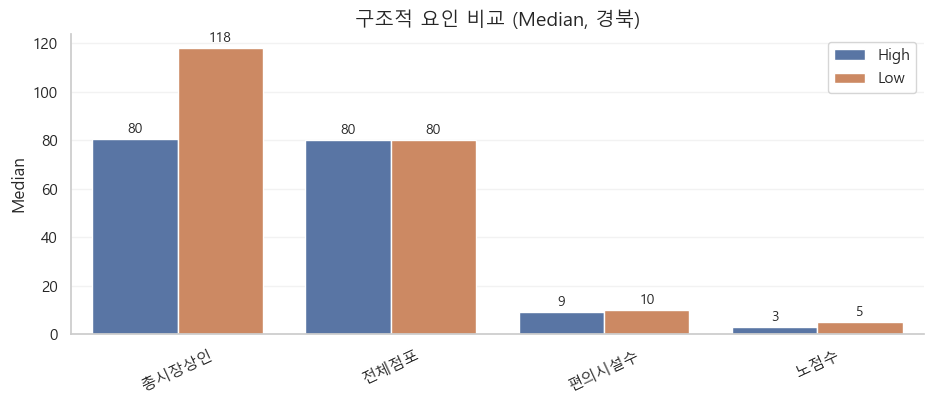

In [28]:
plot_cols1 = ['전체점포','총시장상인', '노점수', '편의시설수']

plot_df1 = prep_compare_df(
    df_high, df_low,
    plot_cols1,
    stat="median",
    value_name="Median"
)

barplot_compare(
    plot_df1,
    title="구조적 요인 비교 (Median, 경북)",
    y_col="Median",
    figsize=(9.5, 4.2),
    rotate=25,
    show_value=True,
    value_fmt="{:.0f}",
    sort_by="High"
)


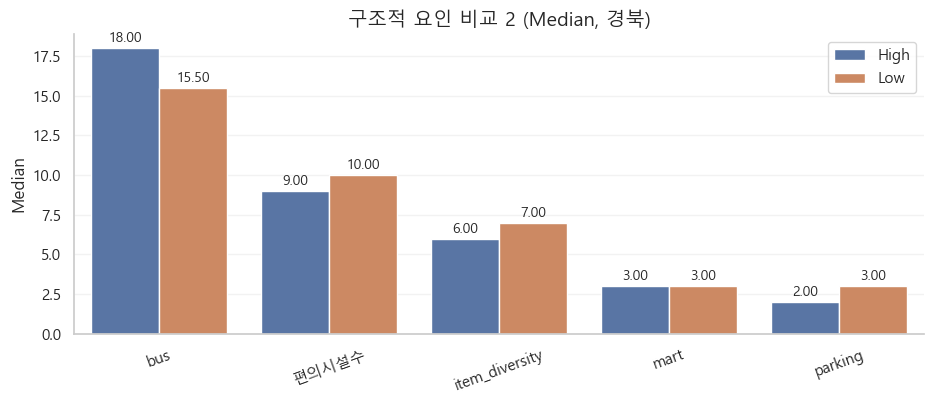

In [32]:
plot_cols2 = ['편의시설수', 'parking', 'bus', 'mart', 'item_diversity']

plot_df2 = prep_compare_df(df_high, df_low, plot_cols2, stat="median", value_name="Median")
barplot_compare(
    plot_df2,
    title="구조적 요인 비교 2 (Median, 경북)",
    y_col="Median",
    figsize=(9.5,4.2),
    rotate=20,
    show_value=True,
    value_fmt="{:.2f}",
    sort_by="mean"          # 평균 기준 정렬(High/Low 중립)
)


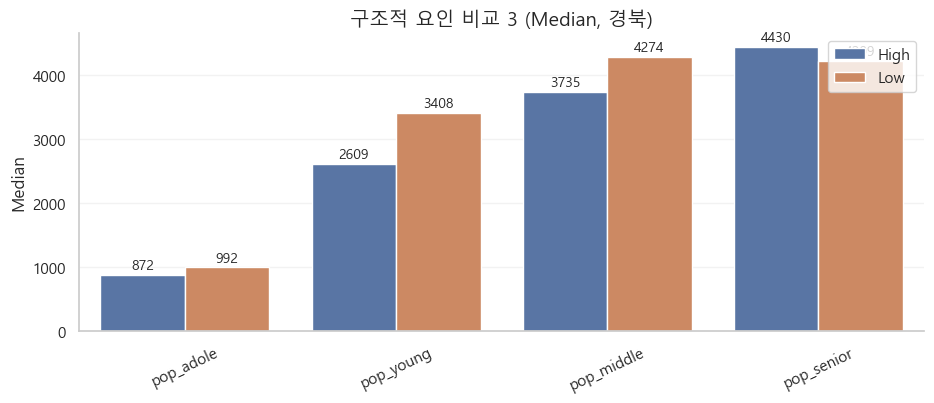

In [33]:
plot_pop = ['pop_adole', 'pop_young', 'pop_middle', 'pop_senior']
plot_df_pop = prep_compare_df(
    df_high, df_low,
    plot_pop,
    stat="median",
    value_name="Median"
)


barplot_compare(
    plot_df_pop,
    title="구조적 요인 비교 3 (Median, 경북)",
    y_col="Median",
    figsize=(9.5, 4.2),
    rotate=25,
    show_value=True,
    value_fmt="{:.0f}"
)


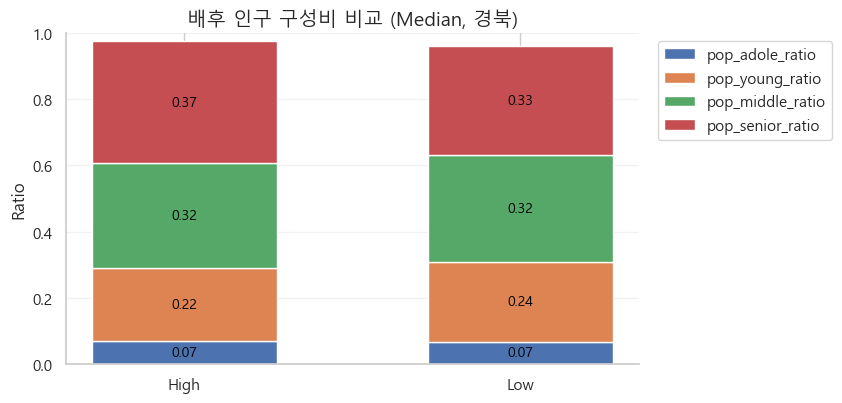

In [34]:
pop_ratio_cols = [
    "pop_adole_ratio",
    "pop_young_ratio",
    "pop_middle_ratio",
    "pop_senior_ratio"
]

stacked_ratio_bar_with_labels(
    df_high_r, df_low_r,
    pop_ratio_cols,
    title="배후 인구 구성비 비교 (Median, 경북)",
    figsize=(8.6, 4.2),
    label_threshold=0.04,
    fmt="{:.2f}"
)


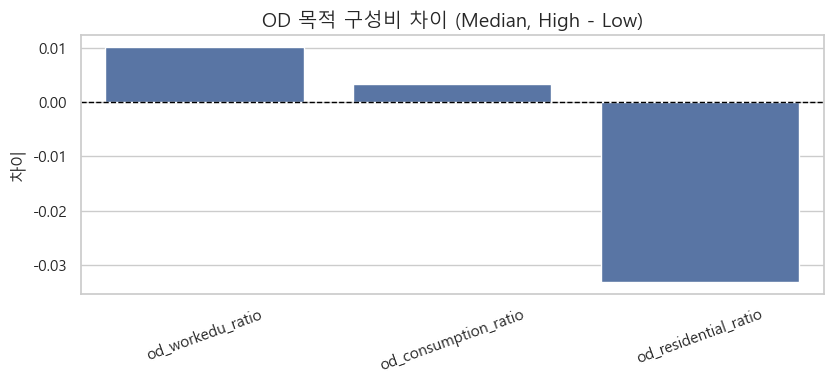

In [35]:
od_purpose_ratio = [
    "od_consumption_ratio",
    "od_residential_ratio",
    "od_workedu_ratio"
]

diff_df = compare_median(df_high_r, df_low_r, od_purpose_ratio)
diff_df = diff_df.reset_index().rename(columns={"index": "구성비 항목"})

fig, ax = plt.subplots(figsize=(8.5, 4))
sns.barplot(data=diff_df, x="구성비 항목", y="Diff", ax=ax, errorbar=None)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("OD 목적 구성비 차이 (Median, High - Low)")
ax.set_xlabel("")
ax.set_ylabel("차이")
ax.tick_params(axis="x", rotation=20)

#for container in ax.containers:
#    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=10)

plt.tight_layout()
plt.show()


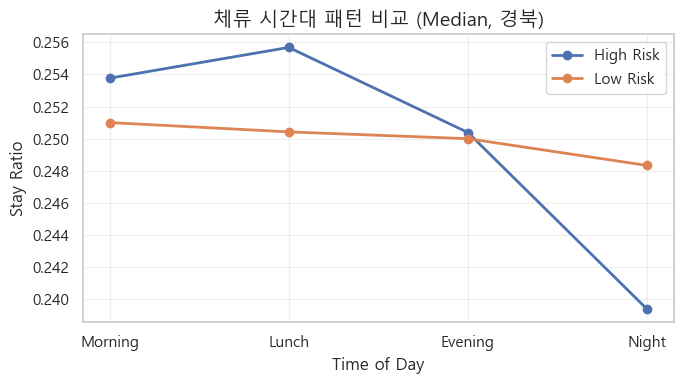

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 체류 시간대 컬럼 (순서 중요)
time_cols = [
    "stay_morning_ratio",
    "stay_lunch_ratio",
    "stay_evening_ratio",
    "stay_night_ratio"
]

# median 값 계산
high_vals = df_high_r[time_cols].median()
low_vals  = df_low_r[time_cols].median()

# x축 라벨용
time_labels = ["Morning", "Lunch", "Evening", "Night"]

plt.figure(figsize=(7, 4))

plt.plot(
    time_labels,
    high_vals.values,
    marker="o",
    linewidth=2,
    label="High Risk"
)

plt.plot(
    time_labels,
    low_vals.values,
    marker="o",
    linewidth=2,
    label="Low Risk"
)

plt.ylabel("Stay Ratio")
plt.xlabel("Time of Day")
plt.title("체류 시간대 패턴 비교 (Median, 경북)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


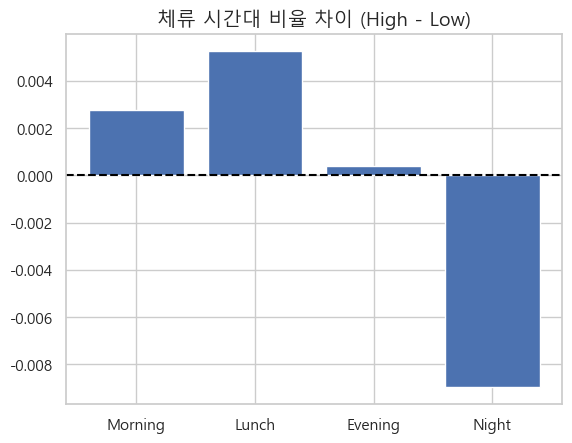

In [37]:
diff_val = high_vals - low_vals
plt.bar(time_labels, diff_val)
plt.axhline(0, color="black", linestyle = '--')
plt.title("체류 시간대 비율 차이 (High - Low)")
plt.show()

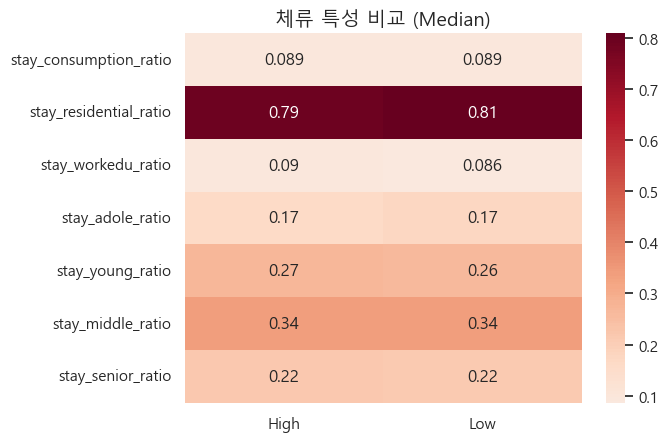

In [38]:
stay_cols = [
    "stay_consumption_ratio", "stay_residential_ratio", "stay_workedu_ratio",

    "stay_adole_ratio", "stay_young_ratio", "stay_middle_ratio", "stay_senior_ratio"
]

heat_df = pd.DataFrame({
    "High": df_high_r[stay_cols].median(),
    "Low": df_low_r[stay_cols].median()
})

sns.heatmap(heat_df, annot=True, cmap="RdBu_r", center=0)
plt.title("체류 특성 비교 (Median)")
plt.show()


## 지도

In [53]:
df_high.loc[df_high['시장명'] == '중앙시장', '위도'] = 36.11902271
df_high.loc[df_high['시장명'] == '중앙시장', '경도'] = 128.3267739


In [106]:
import folium
import pandas as pd

# 컬럼명 맞춰서 수정
LAT_COL = "위도"
LON_COL = "경도"
NAME_COL = "시장명"   # 없으면 None 처리됨

def _clean_points(df, lat_col=LAT_COL, lon_col=LON_COL):
    d = df.copy()
    d = d.dropna(subset=[lat_col, lon_col])
    d[lat_col] = pd.to_numeric(d[lat_col], errors="coerce")
    d[lon_col] = pd.to_numeric(d[lon_col], errors="coerce")
    d = d.dropna(subset=[lat_col, lon_col])

    # 한국 범위 대략 필터(옵션): 이상치 제거
    d = d[(d[lat_col].between(33.0, 39.5)) & (d[lon_col].between(124.0, 132.5))]
    return d

high = _clean_points(df_high)
low  = _clean_points(df_low)

high_cnt = len(high)
low_cnt = len(low)
total_cnt = high_cnt + low_cnt

# 지도 중심: 전체 평균
center_lat = pd.concat([high[LAT_COL], low[LAT_COL]]).mean()
center_lon = pd.concat([high[LON_COL], low[LON_COL]]).mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="CartoDB positron")

# 레이어 분리(켜고 끌 수 있게)
fg_high = folium.FeatureGroup(name=f"High ({high_cnt})", show=True).add_to(m)
fg_low  = folium.FeatureGroup(name=f"Low ({low_cnt})", show=True).add_to(m)

# High 찍기
for _, r in high.iterrows():
    popup_txt = None
    if NAME_COL in high.columns:
        popup_txt = str(r[NAME_COL])

    folium.CircleMarker(
        location=[r[LAT_COL], r[LON_COL]],
        radius=12,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=popup_txt
    ).add_to(fg_high)

# Low 찍기
for _, r in low.iterrows():
    popup_txt = None
    if NAME_COL in low.columns:
        popup_txt = str(r[NAME_COL])

    folium.CircleMarker(
        location=[r[LAT_COL], r[LON_COL]],
        radius=12,
        color="green",
        fill=True,
        fill_opacity=0.7,
        popup=popup_txt
    ).add_to(fg_low)

# ====== (High/Low 점 찍은 후) 지정 좌표 중심으로 큰 원 추가 ======

# 1) 도시 중심 좌표 직접 입력 (위도, 경도)
city_centers = {
    "안동시": (36.5666, 128.7294),
    "포항시": (36.0190, 129.3435), 
    "대구광역시": (35.8714, 128.6015),
}

# 2) 큰 원 반경(미터) 설정
RADIUS_M = 5000  # 예: 15km (원하는 값으로 조절: 10000=10km, 20000=20km)

for city, (lat_c, lon_c) in city_centers.items():
    # 큰 원(미터 단위)
    folium.Circle(
        location=[lat_c, lon_c],
        radius=RADIUS_M,
        color="yellow",
        weight=3,
        fill=True,
        fill_opacity=0.4,
        popup=f"{city} 중심 / 반경 {RADIUS_M/1000:.1f}km"
    ).add_to(m)

    

# 총 개수 오버레이(지도 위 박스)
summary_html = f"""
<div style="
 position: fixed; 
 top: 15px; left: 15px; z-index: 9999;
 background-color: white;
 padding: 10px 12px;
 border: 1px solid #999;
 border-radius: 6px;
 font-size: 14px;
 ">
 <b>전통시장 포인트 개수</b><br>
 High: {high_cnt:,}<br>
 Low: {low_cnt:,}<br>
 <b>Total: {total_cnt:,}</b>
</div>
"""
m.get_root().html.add_child(folium.Element(summary_html))

folium.LayerControl(collapsed=False).add_to(m)

m

In [107]:
# 7) 저장
out_path = r"C:\Users\legen\Desktop\Lab Project\BC\fig\market_risk_map.html"
m.save(out_path)

out_path

'C:\\Users\\legen\\Desktop\\Lab Project\\BC\\fig\\market_risk_map.html'

## 비교2

In [ ]:
['가은아자개시장', '중앙시장']

In [130]:
df_high[df_high['시장명'].isin(['가은아자개시장', '중앙시장'])]

,행정기관코드,시장명,시도,시군구,위도,경도,시장면적,전체점포,노점수,점포상인,...,stay_weekday,stay_holiday,stay_morning,stay_lunch,stay_evening,stay_night,pred,residual,risk_index,risk_group
43,4728025300,가은아자개시장,경상북도,문경시,36.646452,128.060917,26401,95,59,80,...,1538399.0,1932198.0,956825.0,1034967.0,820179.0,658626.0,0.095476,0.062419,1.192368,High
53,4715051600,중앙시장,경상북도,김천시,36.119023,128.326774,15263,90,0,60,...,4249392.0,2746038.0,1827647.0,1853839.0,1767306.0,1546638.0,0.272531,0.060802,1.987466,High


In [131]:
df_low[df_low['시장명'].isin(['문경전통시장', '왜관시장'])]

,행정기관코드,시장명,시도,시군구,위도,경도,시장면적,전체점포,노점수,점포상인,...,stay_weekday,stay_holiday,stay_morning,stay_lunch,stay_evening,stay_night,pred,residual,risk_index,risk_group
44,4728025000,문경전통시장,경상북도,문경시,36.735567,128.107429,21199,66,41,66,...,2870103.0,3288566.0,1575022.0,1821408.0,1501834.0,1260405.0,0.045993,-0.045993,-0.802012,Low
59,4785025000,왜관시장,경상북도,칠곡군,35.995374,128.398209,13368,134,50,129,...,16034135.0,9612590.0,6854126.0,6875981.0,6416948.0,5499670.0,0.035144,-0.035144,-0.675734,Low


In [132]:
pairs = [
    {"region": "문경시", "high": "가은아자개시장", "low": "문경전통시장"},
    {"region": "칠곡군", "high": "중앙시장",     "low": "왜관시장"},
]


In [133]:
BASE_COLS = [
    "전체점포", "점포상인", "노점수", "시장면적",
    "parking", "bus", "편의시설수", "item_diversity",
    "pop_adole", "pop_young", "pop_middle", "pop_senior"
]

POP_RATIO_COLS = [
    "pop_adole_ratio", "pop_young_ratio", "pop_middle_ratio", "pop_senior_ratio"
]

OD_RATIO_COLS = [
    "od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio",
    "od_in_weekday_ratio", "od_in_holiday_ratio",
    "od_modal_car_ratio", "od_modal_bus_ratio", "od_modal_walk_ratio", "od_modal_sub_ratio", "od_modal_etc_ratio",
    "od_adole_ratio", "od_young_ratio", "od_middle_ratio", "od_senior_ratio"
]

STAY_RATIO_COLS = [
    "stay_consumption_ratio", "stay_residential_ratio", "stay_workedu_ratio",
    "stay_weekday_ratio", "stay_holiday_ratio",
    "stay_morning_ratio", "stay_lunch_ratio", "stay_evening_ratio", "stay_night_ratio",
    "stay_adole_ratio", "stay_young_ratio", "stay_middle_ratio", "stay_senior_ratio"
]


In [135]:
import numpy as np
import pandas as pd

def _get_market_row(df, market_name, name_col="시장명"):
    sub = df.loc[df[name_col] == market_name]
    if sub.empty:
        raise ValueError(f"[ERROR] '{market_name}' not found in dataframe")
    if len(sub) > 1:
        # 동일 시장명 중복이면 첫 행 사용 (원하면 시군구 조건 추가)
        sub = sub.iloc[[0]]
    return sub.iloc[0]

def _arrow(diff, eps=1e-9):
    if pd.isna(diff):
        return ""
    if diff > eps:
        return "↑"
    if diff < -eps:
        return "↓"
    return "→"

def compare_market_pair(
    df_high_r, df_low_r,
    high_market, low_market,
    cols,
    name_col="시장명",
    agg="value",   # 지금은 '개별 시장 값' 비교라 value가 기본
    round_digits=3,
):
    """
    같은 시군 내 High 시장 1개 vs Low 시장 1개의 '개별 값' 비교 테이블.
    (median 비교가 아니라 '해당 시장의 값' 그 자체 비교)
    """
    h = _get_market_row(df_high_r, high_market, name_col=name_col)
    l = _get_market_row(df_low_r,  low_market,  name_col=name_col)

    rows = []
    for c in cols:
        hv = h.get(c, np.nan)
        lv = l.get(c, np.nan)
        diff = hv - lv if (pd.notna(hv) and pd.notna(lv)) else np.nan
        rows.append([c, hv, lv, diff, _arrow(diff)])

    out = pd.DataFrame(rows, columns=["Feature", "High_value", "Low_value", "Diff(High-Low)", "Direction"])
    # 보기 좋게 반올림
    for col in ["High_value", "Low_value", "Diff(High-Low)"]:
        out[col] = out[col].astype(float).round(round_digits)

    # Diff 기준 정렬(가장 차이가 큰 것 위)
    out = out.sort_values("Diff(High-Low)")
    return out


In [140]:
df_low_r['od_senior_ratio']

44    0.021750
46    0.041495
48    0.015675
50    0.019687
59    0.026690
Name: od_senior_ratio, dtype: float64

In [141]:
df_high_r['od_senior_ratio']

43    0.008346
53    0.064481
56    0.031048
57    0.033170
58    0.040944
Name: od_senior_ratio, dtype: float64

In [142]:
df_low_r['stay_consumption_ratio']

44    0.299793
46    0.176175
48    0.093521
50    0.044570
59    0.100974
Name: stay_consumption_ratio, dtype: float64

In [143]:
df_high_r['stay_consumption_ratio']

43    0.305443
53    0.065015
56    0.058344
57    0.169805
58    0.086130
Name: stay_consumption_ratio, dtype: float64

In [149]:
KEY_FEATURES = [
    # 구조/메타
    "전체점포", "점포상인", "노점수", "시장면적", "bus", "parking", "편의시설수", "item_diversity",
    # 배후인구(절대)
    "pop_adole", "pop_young", "pop_middle", "pop_senior",
    # 주민등록 구성비
    "pop_adole_ratio", "pop_young_ratio", "pop_middle_ratio", "pop_senior_ratio",
    
    # OD 목적/연령
    "od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio",

    "od_adole_ratio", "od_young_ratio", "od_middle_ratio", "od_senior_ratio",

    # Stay 목적/연령
    "stay_consumption_ratio", "stay_residential_ratio", "stay_workedu_ratio",

    "stay_adole_ratio", "stay_young_ratio", "stay_middle_ratio", "stay_senior_ratio"
]

for p in pairs:
    print(f"\n=== {p['region']} | High: {p['high']} vs Low: {p['low']} ===")
    comp = compare_market_pair(df_high_r, df_low_r, p["high"], p["low"], KEY_FEATURES, round_digits=3)
    display(comp)



=== 문경시 | High: 가은아자개시장 vs Low: 문경전통시장 ===


,Feature,High_value,Low_value,Diff(High-Low),Direction
11,pop_senior,1895.000,3052.000,-1157.000,↓
10,pop_middle,690.000,1461.000,-771.000,↓
9,pop_young,277.000,655.000,-378.000,↓
8,pop_adole,141.000,339.000,-198.000,↓
19,od_adole_ratio,0.211,0.397,-0.186,↓
16,od_consumption_ratio,0.586,0.662,-0.076,↓
21,od_middle_ratio,0.088,0.132,-0.044,↓
14,pop_middle_ratio,0.230,0.265,-0.036,↓
28,stay_middle_ratio,0.323,0.357,-0.034,↓
13,pop_young_ratio,0.092,0.119,-0.027,↓



=== 칠곡군 | High: 중앙시장 vs Low: 왜관시장 ===


,Feature,High_value,Low_value,Diff(High-Low),Direction
10,pop_middle,1661.000,11132.000,-9471.000,↓
11,pop_senior,3067.000,9409.000,-6342.000,↓
9,pop_young,977.000,6064.000,-5087.000,↓
8,pop_adole,317.000,3124.000,-2807.000,↓
1,점포상인,60.000,129.000,-69.000,↓
2,노점수,0.000,50.000,-50.000,↓
0,전체점포,90.000,134.000,-44.000,↓
5,parking,0.000,18.000,-18.000,↓
6,편의시설수,5.000,12.000,-7.000,↓
4,bus,6.000,12.000,-6.000,↓


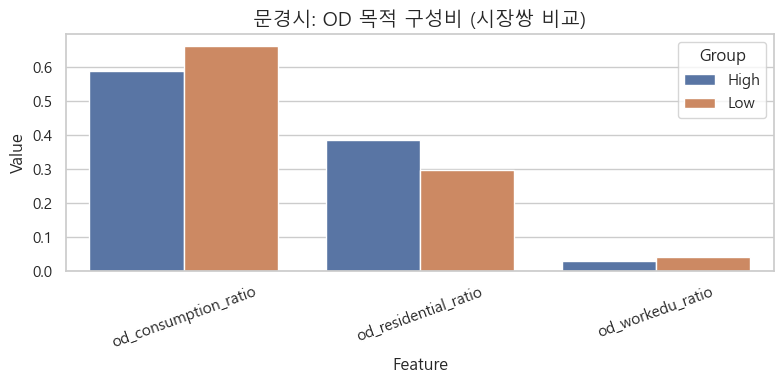

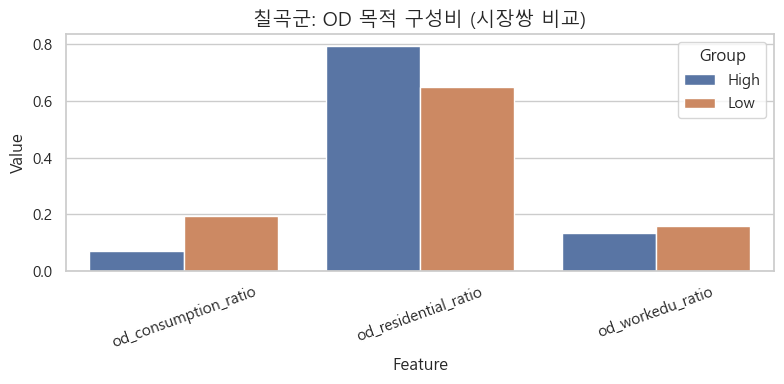

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pair_bar(df_high_r, df_low_r, pair, cols, title, name_col="시장명"):
    h = _get_market_row(df_high_r, pair["high"], name_col)
    l = _get_market_row(df_low_r,  pair["low"],  name_col)

    plot_df = pd.DataFrame({
        "Feature": cols,
        "High": [h.get(c, np.nan) for c in cols],
        "Low":  [l.get(c, np.nan) for c in cols],
    }).melt(id_vars="Feature", var_name="Group", value_name="Value")

    plt.figure(figsize=(8,4))
    sns.barplot(data=plot_df, x="Feature", y="Value", hue="Group", errorbar=None)
    plt.title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

plot_pair_bar(
    df_high_r, df_low_r, pairs[0],
    ["od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio"],
    title="문경시: OD 목적 구성비 (시장쌍 비교)"
)

plot_pair_bar(
    df_high_r, df_low_r, pairs[1],
    ["od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio"],
    title="칠곡군: OD 목적 구성비 (시장쌍 비교)"
)


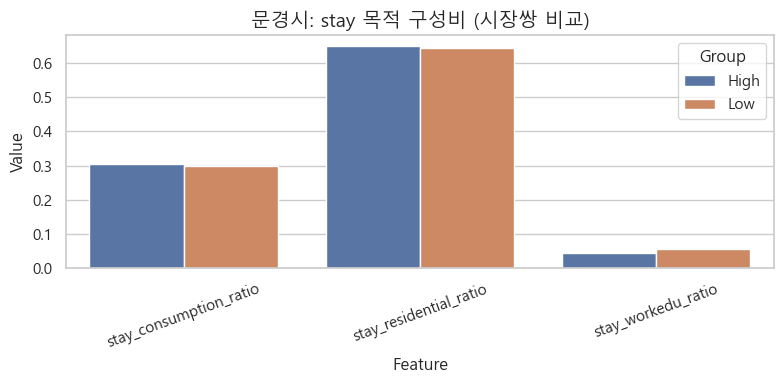

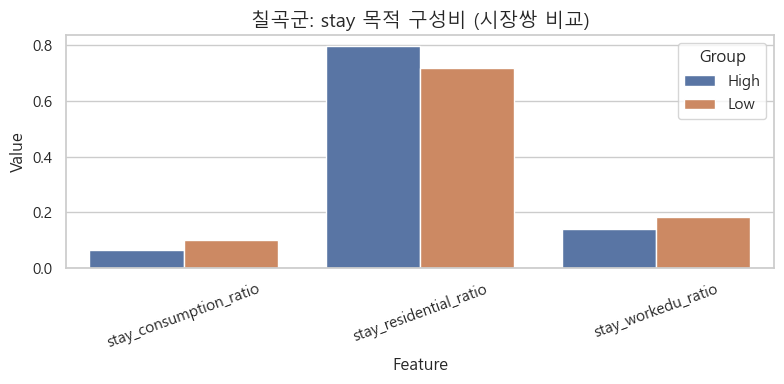

In [154]:
plot_pair_bar(
    df_high_r, df_low_r, pairs[0],
    ["stay_consumption_ratio", "stay_residential_ratio", "stay_workedu_ratio"],
    title="문경시: stay 목적 구성비 (시장쌍 비교)"
)

plot_pair_bar(
    df_high_r, df_low_r, pairs[1],
    ["stay_consumption_ratio", "stay_residential_ratio", "stay_workedu_ratio"],
    title="칠곡군: stay 목적 구성비 (시장쌍 비교)"
)


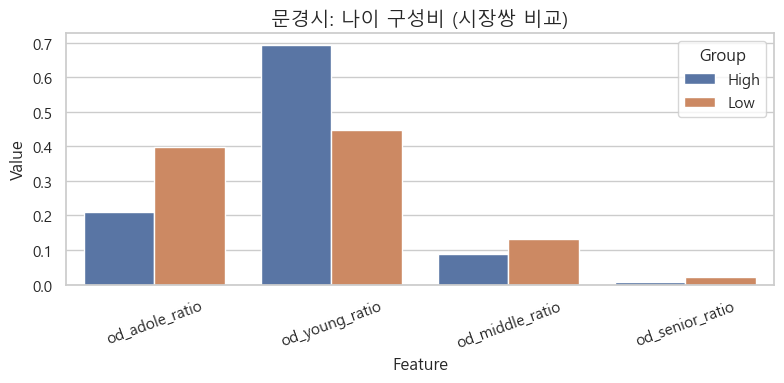

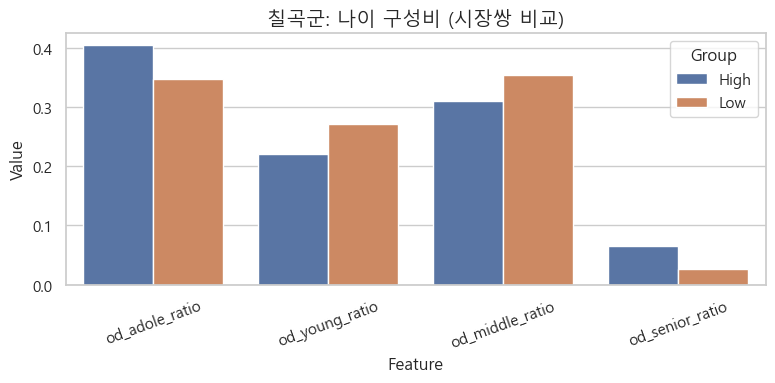

In [151]:
plot_pair_bar(
    df_high_r, df_low_r, pairs[0],
    ["od_adole_ratio", "od_young_ratio", "od_middle_ratio", "od_senior_ratio"],
    title="문경시: 나이 구성비 (시장쌍 비교)"
)

plot_pair_bar(
    df_high_r, df_low_r, pairs[1],
    ["od_adole_ratio", "od_young_ratio", "od_middle_ratio", "od_senior_ratio"],
    title="칠곡군: 나이 구성비 (시장쌍 비교)"
)

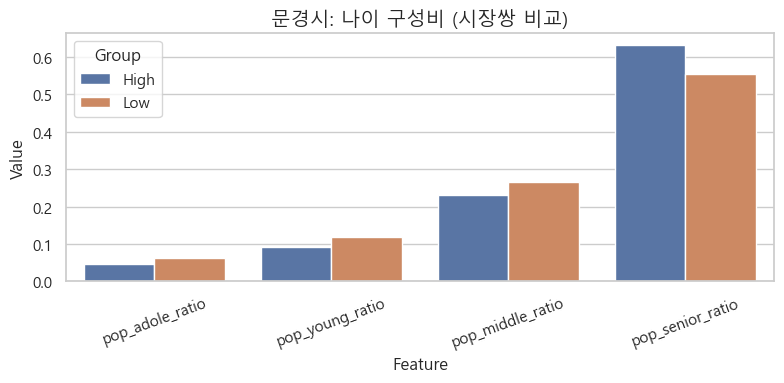

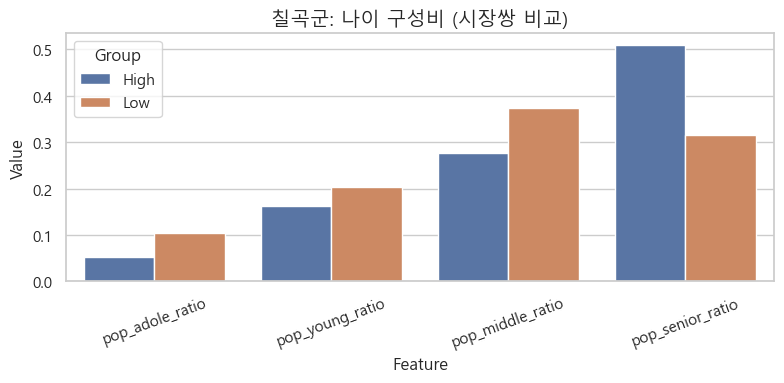

In [152]:
plot_pair_bar(
    df_high_r, df_low_r, pairs[0],
    ["pop_adole_ratio", "pop_young_ratio", "pop_middle_ratio", "pop_senior_ratio"],
    title="문경시: 나이 구성비 (시장쌍 비교)"
)

plot_pair_bar(
    df_high_r, df_low_r, pairs[1],
    ["pop_adole_ratio", "pop_young_ratio", "pop_middle_ratio", "pop_senior_ratio"],
    title="칠곡군: 나이 구성비 (시장쌍 비교)"
)

In [ ]:
plot_pair_bar(
    df_high_r, df_low_r, pairs[0],
    ["od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio"],
    title="문경시: OD 목적 구성비 (시장쌍 비교)"
)

plot_pair_bar(
    df_high_r, df_low_r, pairs[1],
    ["od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio"],
    title="칠곡군: OD 목적 구성비 (시장쌍 비교)"
)

In [199]:
COMPARE_SETS = {
    # 1) OD 목적(소비/거주/업무)
    "od_purpose": {
        "cols": ["od_consumption_ratio", "od_residential_ratio", "od_workedu_ratio"],
        "title": "OD 목적 구성비 (소비/거주/업무)"
    },

    # 1-2) stay 목적(소비/거주/업무)
    "stay_purpose": {
        "cols": ["stay_consumption_ratio", "stay_residential_ratio", "stay_workedu_ratio"],
        "title": "stay 목적 구성비 (소비/거주/업무)"
    },

    # 2) 젊은 유입 (OD 연령 구성비)
    "od_age_young": {
        "cols": ["od_adole_ratio", "od_young_ratio", "od_middle_ratio", "od_senior_ratio"],
        "title": "OD 유입 연령 구성비 (청소년/청년/중장년/고령)"
    },

    # 2-2) 젊은 유입 (stay 연령 구성비)
    "stay_age_young": {
        "cols": ["stay_adole_ratio", "stay_young_ratio", "stay_middle_ratio", "stay_senior_ratio"],
        "title": "stay 유입 연령 구성비 (청소년/청년/중장년/고령)"
    },

    # 3) 거주형 이동 (OD/Stay 목적의 거주 비중 + 체류 거주 비중)
    "residential_mobility": {
        "cols": ["od_residential_ratio", "stay_residential_ratio"],
        "title": "거주형 이동/체류 비중 (OD 거주 vs Stay 거주)"
    },

    # 4) 시설/규모 (구조적 요인)
    "infra_scale": {
        "cols": ["전체점포", "점포상인", "노점수", "편의시설수", "bus", "parking", "item_diversity", 'mart', 'tour'],
        "title": "시설/규모 비교 (구조적 요인)"
    },
}


In [200]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pair_bar(
    df_high_r, df_low_r,
    pair,
    cols,
    title,
    name_col="시장명",
    standardize=False,      # True면 컬럼별 z-score로 스케일 맞춤
    show_values=True,       # 막대 위 값 라벨
    value_fmt="{:.2f}",
    figsize=(8, 4),
    rotate=20
):
    h = _get_market_row(df_high_r, pair["high"], name_col)
    l = _get_market_row(df_low_r, pair["low"],  name_col)

    wide = pd.DataFrame({
        "Feature": cols,
        "High": [h.get(c, np.nan) for c in cols],
        "Low":  [l.get(c, np.nan) for c in cols],
    })

    # 표준화(각 Feature별로 High/Low 두 값 기준 z-score)
    if standardize:
        for i in range(len(wide)):
            vals = wide.loc[i, ["High", "Low"]].astype(float)
            mu = vals.mean()
            sd = vals.std(ddof=0)
            if sd == 0 or np.isnan(sd):
                wide.loc[i, ["High", "Low"]] = 0.0
            else:
                wide.loc[i, ["High", "Low"]] = (vals - mu) / sd
        ylabel = "Z-score (within feature)"
    else:
        ylabel = "Value"

    plot_df = wide.melt(id_vars="Feature", var_name="Group", value_name="Value")

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=plot_df, x="Feature", y="Value", hue="Group", ax=ax, errorbar=None)

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotate)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 값 라벨
    if show_values and not standardize:
        for container in ax.containers:
            labels = [value_fmt.format(v) if pd.notna(v) else "" for v in container.datavalues]
            ax.bar_label(container, labels=labels, padding=2, fontsize=10)

    ax.legend(title="", frameon=True)
    plt.tight_layout()
    plt.show()


In [196]:
pd.concat([df_high_r[df_high_r['시장명'] == '중앙시장'], df_low_r[df_low_r['시장명'] == '왜관시장']], axis=0).to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_low_1.csv", encoding='utf-8-sig', index_label = False)

In [197]:
pd.concat([df_high_r[df_high_r['시장명'] == '가은아자개시장'], df_low_r[df_low_r['시장명'] == '문경전통시장']], axis=0).to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_low_2.csv", encoding='utf-8-sig', index_label = False)

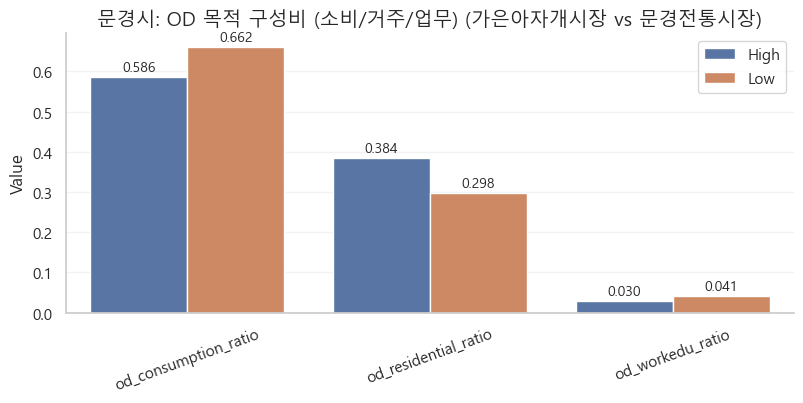

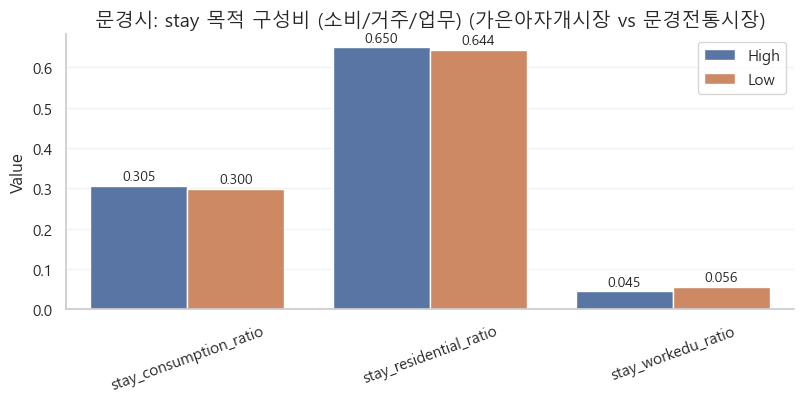

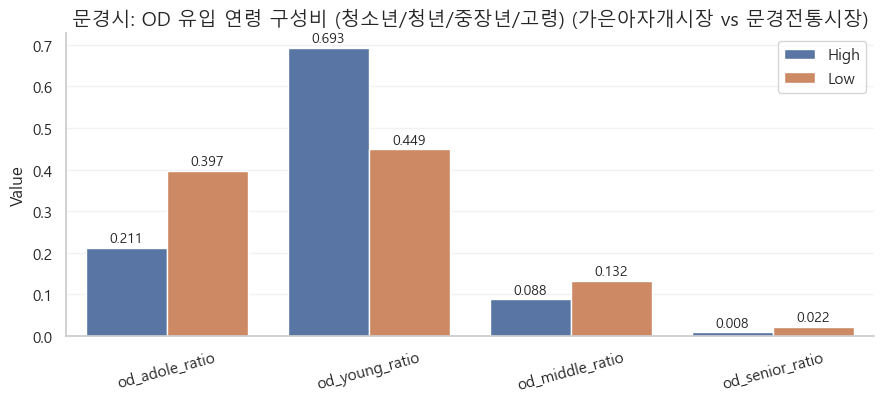

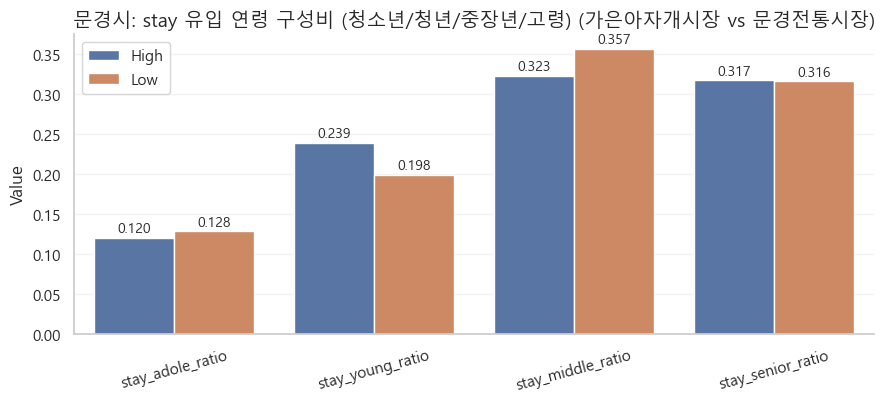

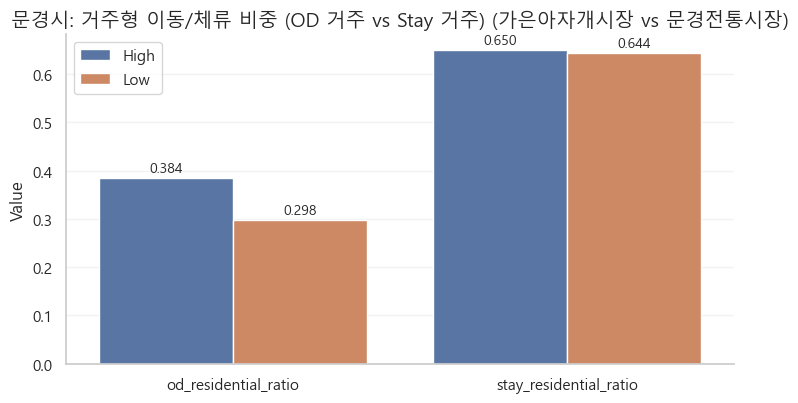

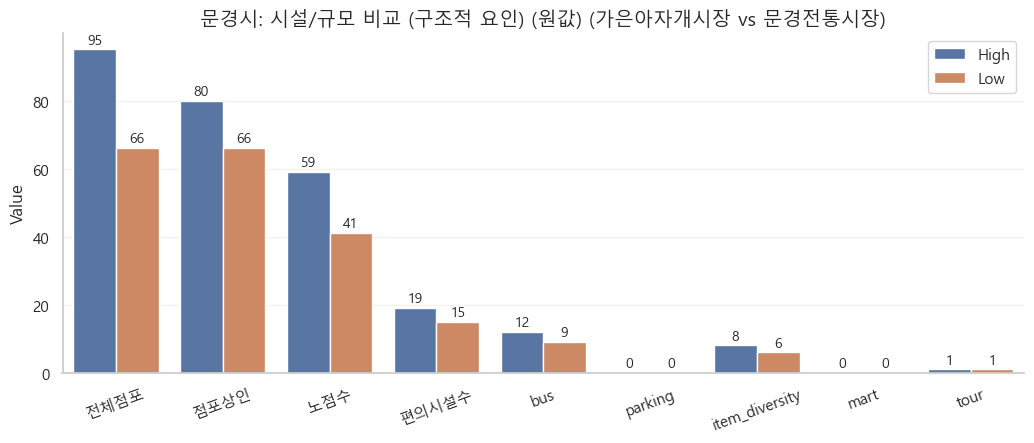

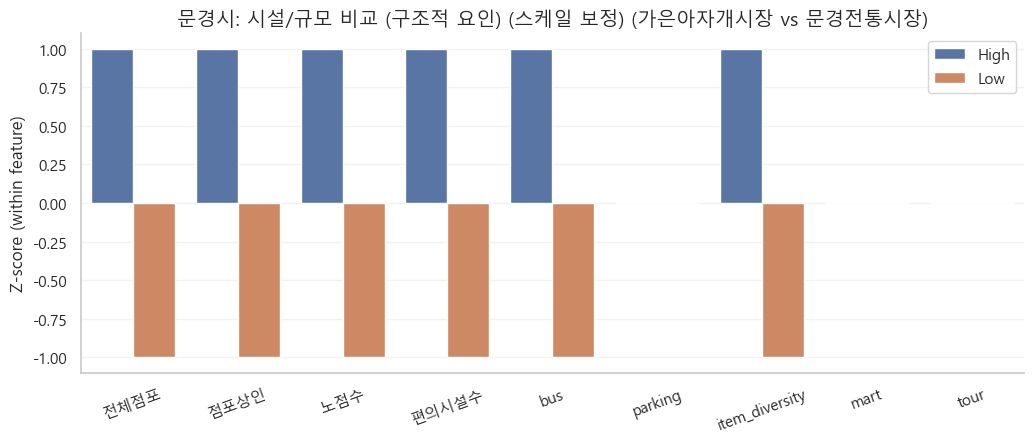

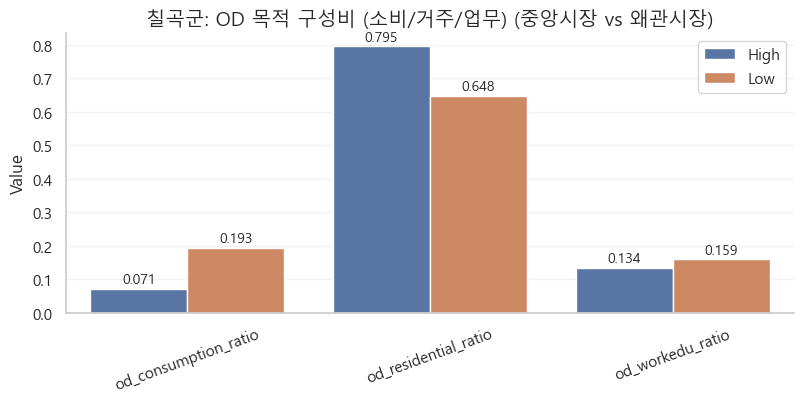

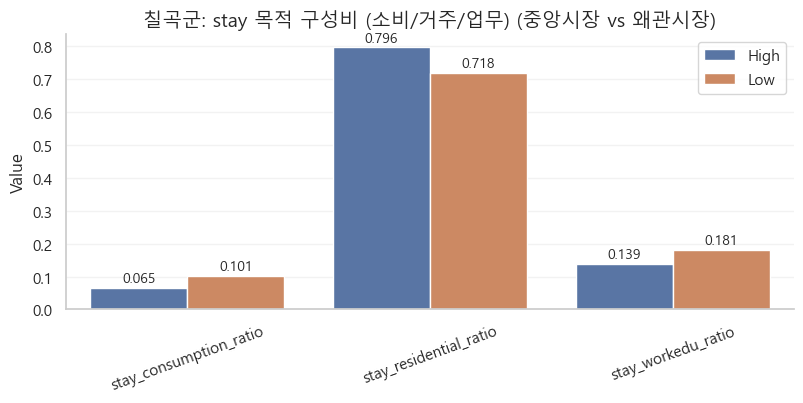

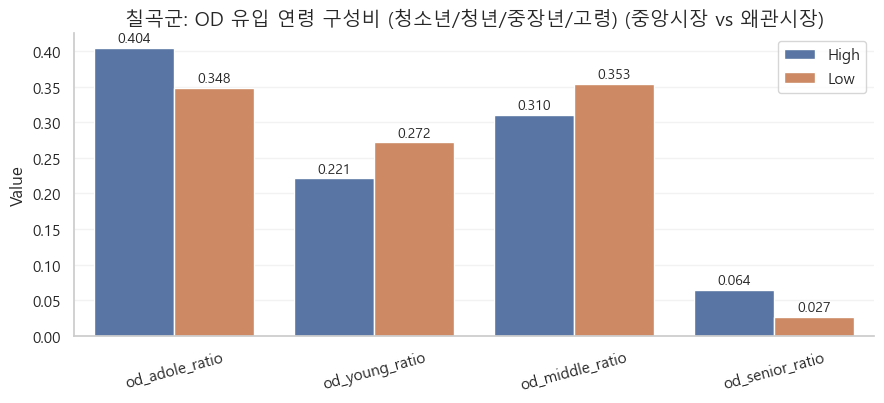

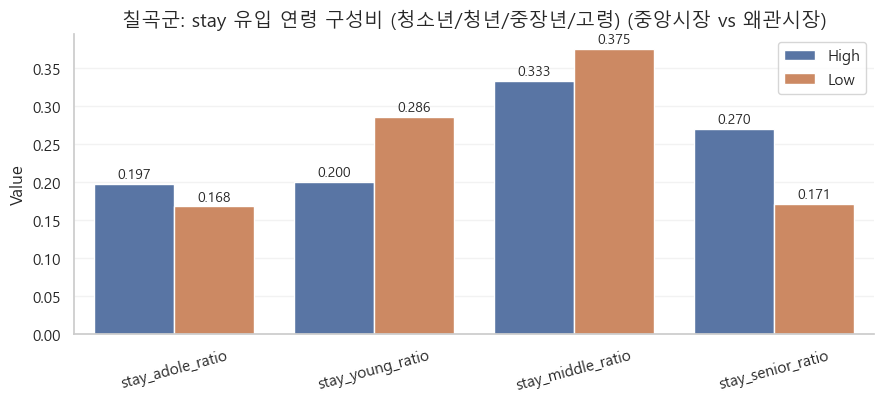

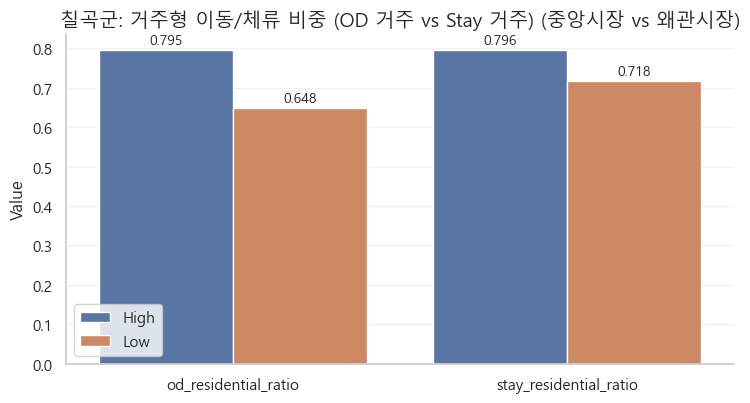

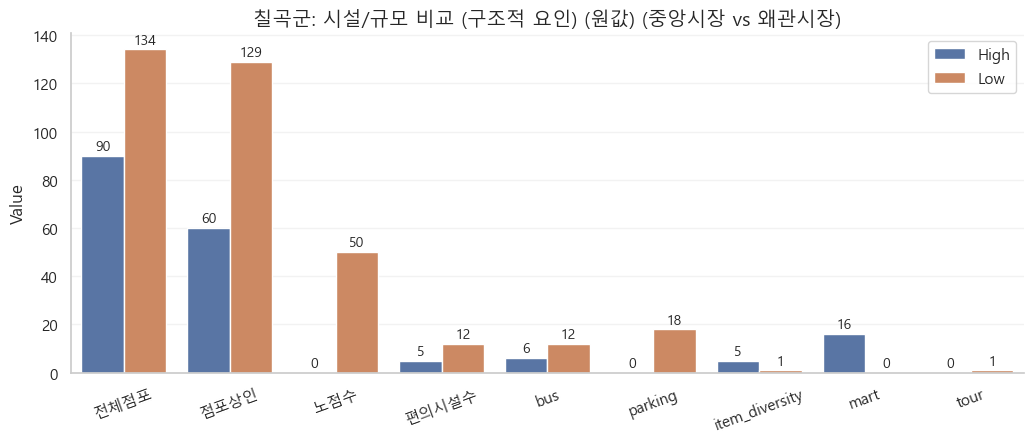

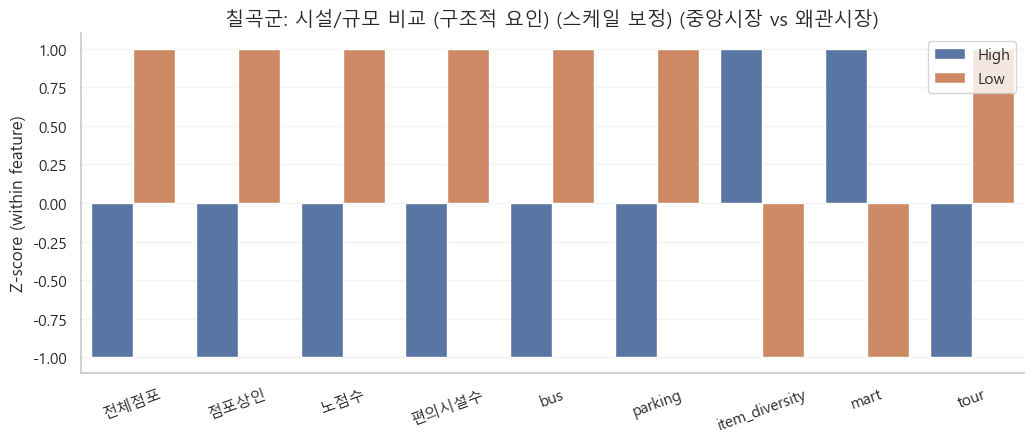

In [201]:
def plot_pair_bundle(df_high_r, df_low_r, pair, name_col="시장명"):
    region = pair.get("region", "")
    high_name = pair["high"]
    low_name = pair["low"]

    # 1) OD 목적
    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["od_purpose"]["cols"],
        title=f"{region}: {COMPARE_SETS['od_purpose']['title']} ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=False,
        value_fmt="{:.3f}",
        figsize=(8.2, 4.2)
    )

    # 1-2) stay 목적
    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["stay_purpose"]["cols"],
        title=f"{region}: {COMPARE_SETS['stay_purpose']['title']} ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=False,
        value_fmt="{:.3f}",
        figsize=(8.2, 4.2)
    )

    # 2) 젊은 유입 (OD 연령)
    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["od_age_young"]["cols"],
        title=f"{region}: {COMPARE_SETS['od_age_young']['title']} ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=False,
        value_fmt="{:.3f}",
        figsize=(9.0, 4.2),
        rotate=15
    )

    # 2-2) 젊은 유입 (stay 연령)
    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["stay_age_young"]["cols"],
        title=f"{region}: {COMPARE_SETS['stay_age_young']['title']} ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=False,
        value_fmt="{:.3f}",
        figsize=(9.0, 4.2),
        rotate=15
    )

    # 3) 거주형 이동/체류
    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["residential_mobility"]["cols"],
        title=f"{region}: {COMPARE_SETS['residential_mobility']['title']} ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=False,
        value_fmt="{:.3f}",
        figsize=(7.6, 4.2),
        rotate=0
    )

    # 4) 시설/규모: 원값 + (옵션) 표준화 둘 다 추천
    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["infra_scale"]["cols"],
        title=f"{region}: {COMPARE_SETS['infra_scale']['title']} (원값) ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=False,
        value_fmt="{:.0f}",
        figsize=(10.5, 4.6),
        rotate=20
    )

    plot_pair_bar(
        df_high_r, df_low_r, pair,
        COMPARE_SETS["infra_scale"]["cols"],
        title=f"{region}: {COMPARE_SETS['infra_scale']['title']} (스케일 보정) ({high_name} vs {low_name})",
        name_col=name_col,
        standardize=True,     # 패턴 비교용
        show_values=False,    # z-score는 라벨 생략이 깔끔
        figsize=(10.5, 4.6),
        rotate=20
    )

# 실행: 문경/칠곡 각각
plot_pair_bundle(df_high_r, df_low_r, pairs[0])
plot_pair_bundle(df_high_r, df_low_r, pairs[1])


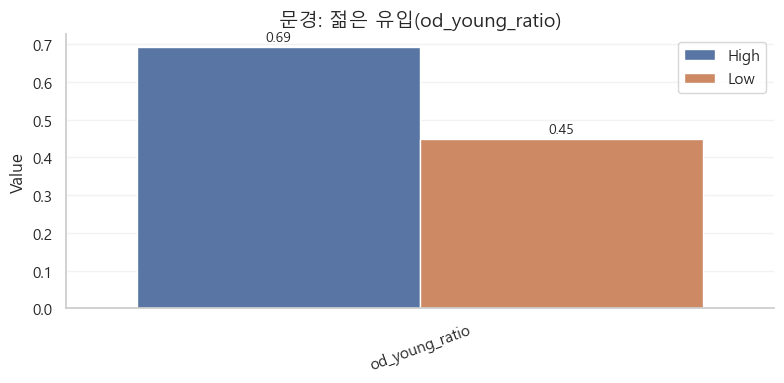

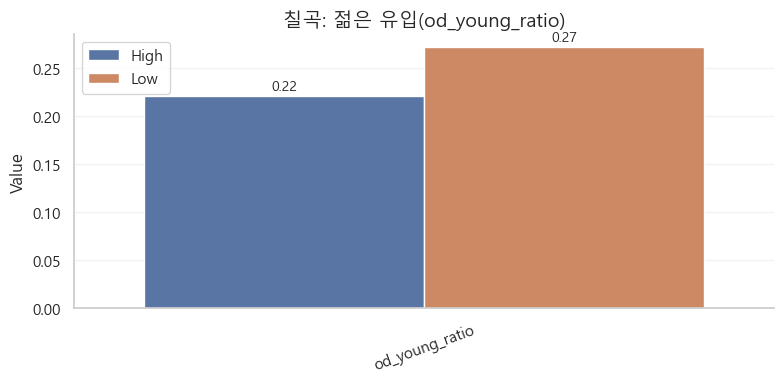

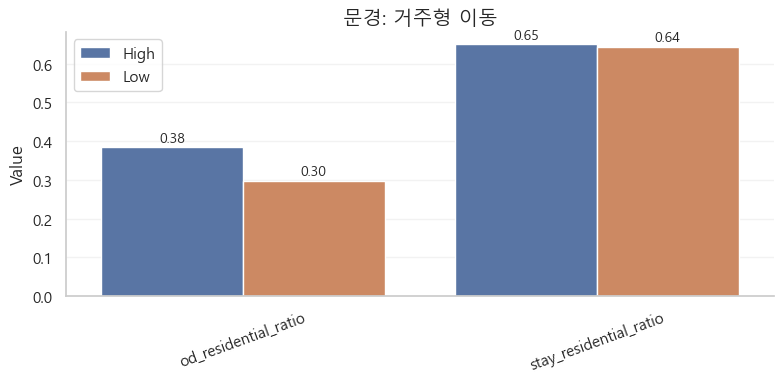

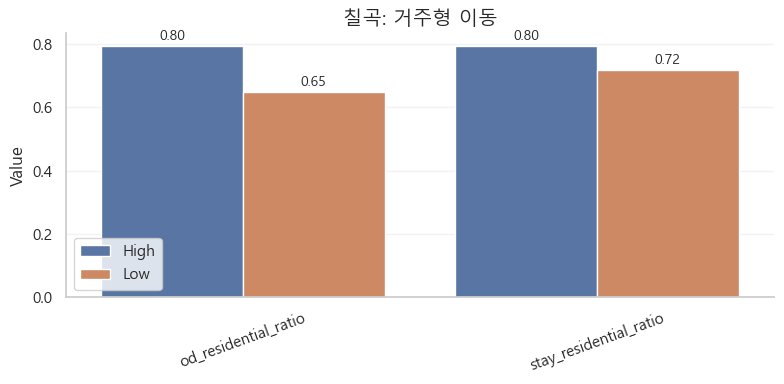

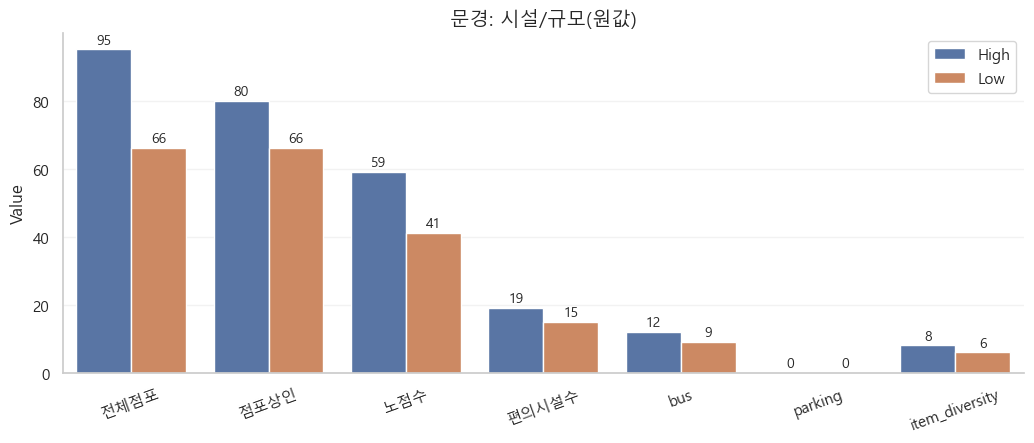

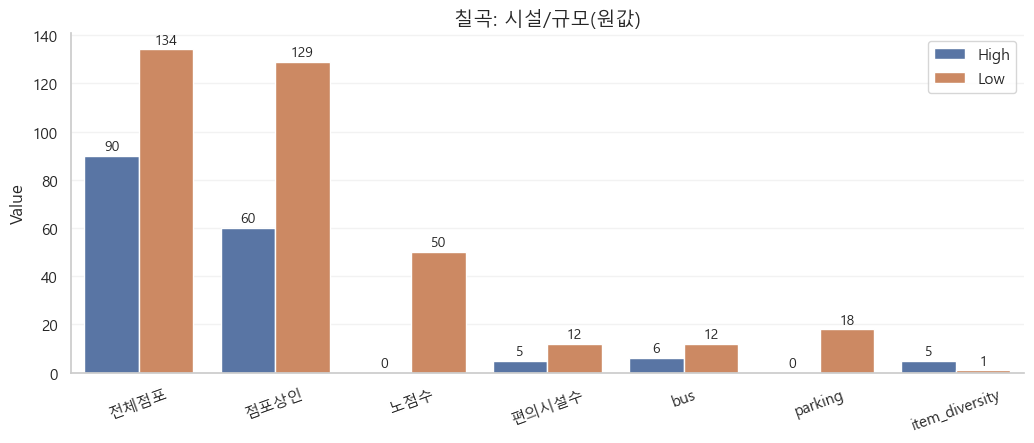

In [193]:
# 젊은 유입 (핵심)
plot_pair_bar(df_high_r, df_low_r, pairs[0], ["od_young_ratio"], "문경: 젊은 유입(od_young_ratio)")
plot_pair_bar(df_high_r, df_low_r, pairs[1], ["od_young_ratio"], "칠곡: 젊은 유입(od_young_ratio)")

# 거주형 이동 (핵심)
plot_pair_bar(df_high_r, df_low_r, pairs[0], ["od_residential_ratio", "stay_residential_ratio"], "문경: 거주형 이동")
plot_pair_bar(df_high_r, df_low_r, pairs[1], ["od_residential_ratio", "stay_residential_ratio"], "칠곡: 거주형 이동")

# 시설/규모 (핵심)
plot_pair_bar(df_high_r, df_low_r, pairs[0],
              ["전체점포","점포상인","노점수","편의시설수","bus","parking","item_diversity"],
              "문경: 시설/규모(원값)", value_fmt="{:.0f}", figsize=(10.5,4.6))
plot_pair_bar(df_high_r, df_low_r, pairs[1],
              ["전체점포","점포상인","노점수","편의시설수","bus","parking","item_diversity"],
              "칠곡: 시설/규모(원값)", value_fmt="{:.0f}", figsize=(10.5,4.6))
